# ADRL — Programming Assignment 1

Generative models for multispectral satellite images, ECG signals and 3D point clouds.

This notebook brings together the three executed notebooks with mathematical explanations and observations. Their code, execution counts and saved outputs are preserved. The results below come from those original runs; this combined file has not been rerun. No execution or dataset download is needed to read the saved results.

**Dataset update:** the course announcement supplied with the assignment replaces Human3.6M with **[ModelNet40 on Kaggle](https://www.kaggle.com/datasets/balraj98/modelnet40-princeton-3d-object-dataset)**. Q3 therefore retains its ModelNet40 implementation and results.

- **Q1:** [EuroSAT on Kaggle](https://www.kaggle.com/datasets/apollo2506/eurosat-dataset), using all 13 bands of the TIFF images.
- **Q2:** [MIT-BIH Arrhythmia on PhysioNet](https://physionet.org/content/mitdb/1.0.0/), using normal (N) and premature ventricular contraction (V) beats.
- **Q3:** ModelNet40 object meshes, with 256 sampled surface points per object.

## Q1.1 — Custom f-GAN

For $u>0$, let $f(u)=u\log u-u+1$. Its convex conjugate is

$$
f^*(t)=\sup_{u>0}\{ut-f(u)\}.
$$

The derivative of the expression being maximized is $t-\log u$, which vanishes at $u=e^t$. The second derivative is $-1/u<0$, so this stationary point is the unique maximizer. Substituting gives

$$
f^*(t)=te^t-(te^t-e^t+1)=e^t-1.
$$

This is finite for every real $t$, hence $\operatorname{dom}f^*=\mathbb R$.

Therefore the discriminator output activation is $g_f(v)=v$, equivalent to `torch.nn.Identity()`. Its image is all of $\mathbb R$, exactly the allowed domain. No finite upper or lower bound is required; a sigmoid or tanh would unnecessarily restrict the variational family. The instruction to strictly bound the output does not impose a nontrivial bound for this particular conjugate.

The variational objective is

$$
\max_D\;\mathbb E_{x\sim p_{\rm data}}[T(x)]-\mathbb E_z[f^*(T(G(z)))].
$$

In the saved implementation, the convolutional discriminator produces a spatial patch map and averages it to obtain one scalar $T(x)$ per image. The losses are

$$
L_D=-\mathbb E[T(x)]+\mathbb E[e^{T(G(z))}-1],\qquad
L_G=-\mathbb E[e^{T(G(z))}-1].
$$

These equations describe the existing code: the exponential is applied to the image-level averaged score. Averaging exponentials over individual patch scores would be a different objective and is not substituted here.

The first convolution's gradient is captured immediately after the first discriminator backward pass of epoch 1, batch 1, before the optimizer step. Its reported L2 norm is the square root of the sum of squared entries of that saved gradient tensor.

Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Reading normalization values: 5000/22077
Reading normalization values: 10000/22077
Reading normalization values: 15000/22077
Reading normalization values: 20000/22077
Dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Training images: 22077 Validation images: 5520
Epoch 1, Batch 1: first convolution gradient L2 = 0.6918411048350842
Epoch 1/20: D = 0.045338, G = -0.208186
Epoch 2/20: D = 6553.383093, G = 0.493317
Epoch 3/20: D = 17.054027, G = 1.000000
Epoch 4/20: D = 16.434739, G = 1.000000
Epoch 5/20: D = 15.729120, G = 1.000000
Epoch 6/20: D = 14.974172, G = 1.000000
Epoch 7/20: D = 14.136410, G = 1.000000
Epoch 8/20: D = 13.162002, G = 1.000000
Epoch 9/20: D = 11.834643, G = 1.000000
Epoch 10/20: D = 9.782988, G = 1.000000
Epoch 11/20: D = 6.601399, G = 1.000000
Epoch 12/20: D = 2.530470, G = 1.000000
Epoch 13/20: D = 3335.640863, G = -33.166972
Epoch 1

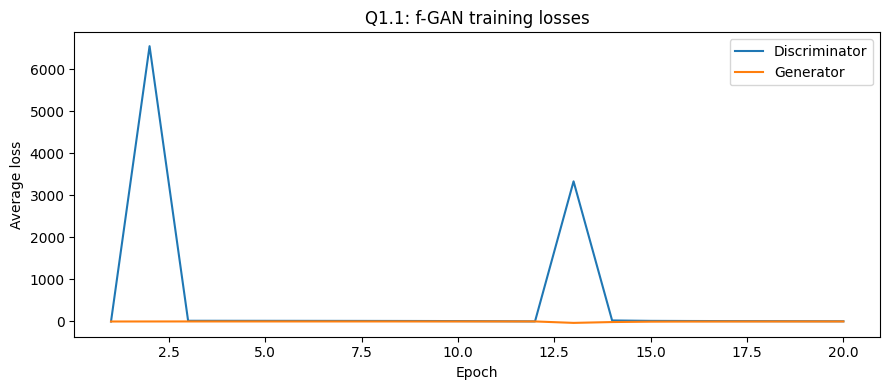

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt


SEED = 2026
DATA_ROOT =  Path('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands')
OUTPUT_DIR = Path('/kaggle/working/q1_1_fgan_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
LEARNING_RATE = 0.0002


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


def prepare_data():
    root = DATA_ROOT
    if root is None:
        folders = sorted(p for p in Path('/kaggle/input').rglob('EuroSATAllBands')
                         if p.is_dir() and (p / 'AnnualCrop').is_dir())
        if len(folders) != 1:
            raise ValueError('Set DATA_ROOT to your EuroSATAllBands folder. '
                             f'Found these candidates: {folders}')
        root = folders[0]
    root = Path(root)
    classes = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                      'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                      'River', 'SeaLake'])
    root, class_folders = find_dataset(
        DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', classes)
    train_files, validation_files = [], []
    rng = np.random.default_rng(SEED)

    # The guide uses a seeded 80/20 split within each class.
    for name in classes:
        files = sorted(p for p in (root / name).rglob('*'))
        files = sorted(p for p in class_folders[name].rglob('*')
                       if p.is_file() and p.suffix.lower() in ('.tif', '.tiff'))
        if len(files) < 2:
            raise ValueError(f'No usable TIFF class folder: {root / name}')
        order = rng.permutation(len(files))
        split = max(1, min(len(files) - 1, int(0.8 * len(files))))
        train_files.extend(files[i] for i in order[:split])
        validation_files.extend(files[i] for i in order[split:])
    train_files.sort()
    validation_files.sort()

    # Fit normalization using training images only, separately for each band.
    minimum = np.full(13, np.inf, dtype=np.float32)
    maximum = np.full(13, -np.inf, dtype=np.float32)
    for i, path in enumerate(train_files):
        image = read_image(path)
        minimum = np.minimum(minimum, image.min(axis=(1, 2)))
        maximum = np.maximum(maximum, image.max(axis=(1, 2)))
        if (i + 1) % 5000 == 0:
            print(f'Reading normalization values: {i + 1}/{len(train_files)}')
    if np.any(maximum <= minimum):
        raise ValueError('A band has no variation. Check the dataset.')
    print('Dataset:', root)
    print('Training images:', len(train_files), 'Validation images:', len(validation_files))
    return train_files, validation_files, minimum, maximum


class EuroSATDataset(Dataset):
    def __init__(self, files, minimum, maximum):
        self.files = files
        self.minimum = minimum[:, None, None]
        self.maximum = maximum[:, None, None]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = read_image(self.files[index])
        image = 2 * (image - self.minimum) / (self.maximum - self.minimum) - 1
        return torch.from_numpy(image)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))


def leaky_relu(x):
    return torch.where(x >= 0, x, 0.2 * x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 1, 3, 1, 1)

    def forward(self, x):
        x = leaky_relu(self.conv1(x))
        x = leaky_relu(self.conv2(x))
        x = leaky_relu(self.conv3(x))
        patches = self.conv4(x)
        scores = patches.mean(dim=(1, 2, 3))
        return scores  # g_f(v) = v: identity, because the domain is all real numbers.


def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        nn.init.zeros_(layer.bias)


def f_star(t):
    return torch.expm1(t)  # f*(t) = exp(t) - 1, for f(u) = u log(u) - u + 1.


def check_gradients(model):
    for parameter in model.parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise FloatingPointError('Missing or nonfinite gradient; training stopped.')


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    train_files, validation_files, minimum, maximum = prepare_data()
    dataset = EuroSATDataset(train_files, minimum, maximum)
    loader_rng = torch.Generator().manual_seed(SEED)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, generator=loader_rng)
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    generator.apply(initialize_weights)
    discriminator.apply(initialize_weights)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    noise_rng = torch.Generator(device=device).manual_seed(SEED)
    d_history, g_history = [], []

    for epoch in range(EPOCHS):
        d_total, g_total, image_count = 0.0, 0.0, 0
        for batch_number, real in enumerate(loader):
            real = real.to(device)
            batch_size = real.shape[0]

            # Step 1: train the discriminator to maximize the variational bound.
            optimizer_d.zero_grad(set_to_none=True)
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
            with torch.no_grad():
                fake = generator(z)
            real_scores = discriminator(real)
            fake_scores = discriminator(fake)
            loss_d = -real_scores.mean() + f_star(fake_scores).mean()
            if not torch.isfinite(loss_d):
                raise FloatingPointError('Nonfinite discriminator loss; training stopped.')
            loss_d.backward()

            # Capture the requested tensor BEFORE the first optimizer step.
            if epoch == 0 and batch_number == 0:
                gradient = discriminator.conv1.weight.grad.detach().cpu().clone()
                gradient_norm = gradient.double().square().sum().sqrt().item()
                if not np.isfinite(gradient_norm):
                    raise FloatingPointError('Nonfinite first gradient norm.')
                torch.save({'gradient': gradient, 'gradient_l2': gradient_norm},
                           OUTPUT_DIR / 'first_batch_gradient.pt')
                print('Epoch 1, Batch 1: first convolution gradient L2 =', repr(gradient_norm))

            check_gradients(discriminator)
            optimizer_d.step()
            optimizer_d.zero_grad(set_to_none=True)

            # Step 2: train the generator through the fixed discriminator.
            discriminator.requires_grad_(False)
            optimizer_g.zero_grad(set_to_none=True)
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
            fake = generator(z)
            loss_g = -f_star(discriminator(fake)).mean()
            if not torch.isfinite(loss_g):
                raise FloatingPointError('Nonfinite generator loss; training stopped.')
            loss_g.backward()
            check_gradients(generator)
            optimizer_g.step()
            discriminator.requires_grad_(True)

            d_total += loss_d.item() * batch_size
            g_total += loss_g.item() * batch_size
            image_count += batch_size

        d_history.append(d_total / image_count)
        g_history.append(g_total / image_count)
        print(f'Epoch {epoch + 1}/{EPOCHS}: D = {d_history[-1]:.6f}, G = {g_history[-1]:.6f}')

    torch.save({'generator': generator.state_dict(), 'discriminator': discriminator.state_dict(),
                'minimum': torch.from_numpy(minimum), 'maximum': torch.from_numpy(maximum),
                'train_files': [str(p) for p in train_files],
                'validation_files': [str(p) for p in validation_files],
                'discriminator_losses': d_history, 'generator_losses': g_history,
                'seed': SEED, 'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
                'latent_dim': LATENT_DIM, 'learning_rate': LEARNING_RATE,
                'gradient_l2': gradient_norm}, OUTPUT_DIR / 'fgan_results.pt')

    plt.figure(figsize=(9, 4))
    plt.plot(range(1, EPOCHS + 1), d_history, label='Discriminator')
    plt.plot(range(1, EPOCHS + 1), g_history, label='Generator')
    plt.xlabel('Epoch')
    plt.ylabel('Average loss')
    plt.title('Q1.1: f-GAN training losses')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_losses.png')
    plt.show()


if __name__ == '__main__':
    main()

## Q1.2 — BiGAN and latent adversarial attack

The encoder and generator compete with a discriminator on joint pairs $(x,E(x))$ and $(G(z),z)$. A flat latent vector is broadcast across the spatial dimensions and concatenated with the image channels. The adversarial losses use a stable logistic expression implemented directly.

After training, all model parameters are frozen. Validation image 42 is recorded for traceability; the specified attack objective itself depends only on the generated pair, not on a reconstruction of that image. Starting from random $z_0$, perform exactly 50 ascent updates:

$$
z_{k+1}=z_k+\eta\nabla_{z_k}\log\sigma(D(G(z_k),z_k)).
$$

Compare the before/after histograms for every spectral band and report $\|z_{50}-z_0\|_2$. Only the latent vector changes during this attack.

Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Reading normalization values: 5000/22077
Reading normalization values: 10000/22077
Reading normalization values: 15000/22077
Reading normalization values: 20000/22077
Dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Training images: 22077 Validation images: 5520
Validation image 42: {'index': 42, 'path': '/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands/AnnualCrop/AnnualCrop_1168.tif', 'class_name': 'AnnualCrop'}
Epoch 1/20: D=1.414566, G+E=1.479593
Epoch 2/20: D=1.399019, G+E=1.547384
Epoch 3/20: D=1.407933, G+E=1.759470
Epoch 4/20: D=1.292264, G+E=3.800640
Epoch 5/20: D=1.406545, G+E=1.633442
Epoch 6/20: D=1.383362, G+E=1.603834
Epoch 7/20: D=1.369132, G+E=1.784010
Epoch 8/20: D=1.357846, G+E=1.821439
Epoch 9/20: D=1.415593, G+E=1.755960
Epoch 10/20: D=1.384593, G+E=1.623882
Epoch 11/20: D=1.406822, G+E=1.632808
Epoch 12/20: D=1.401602

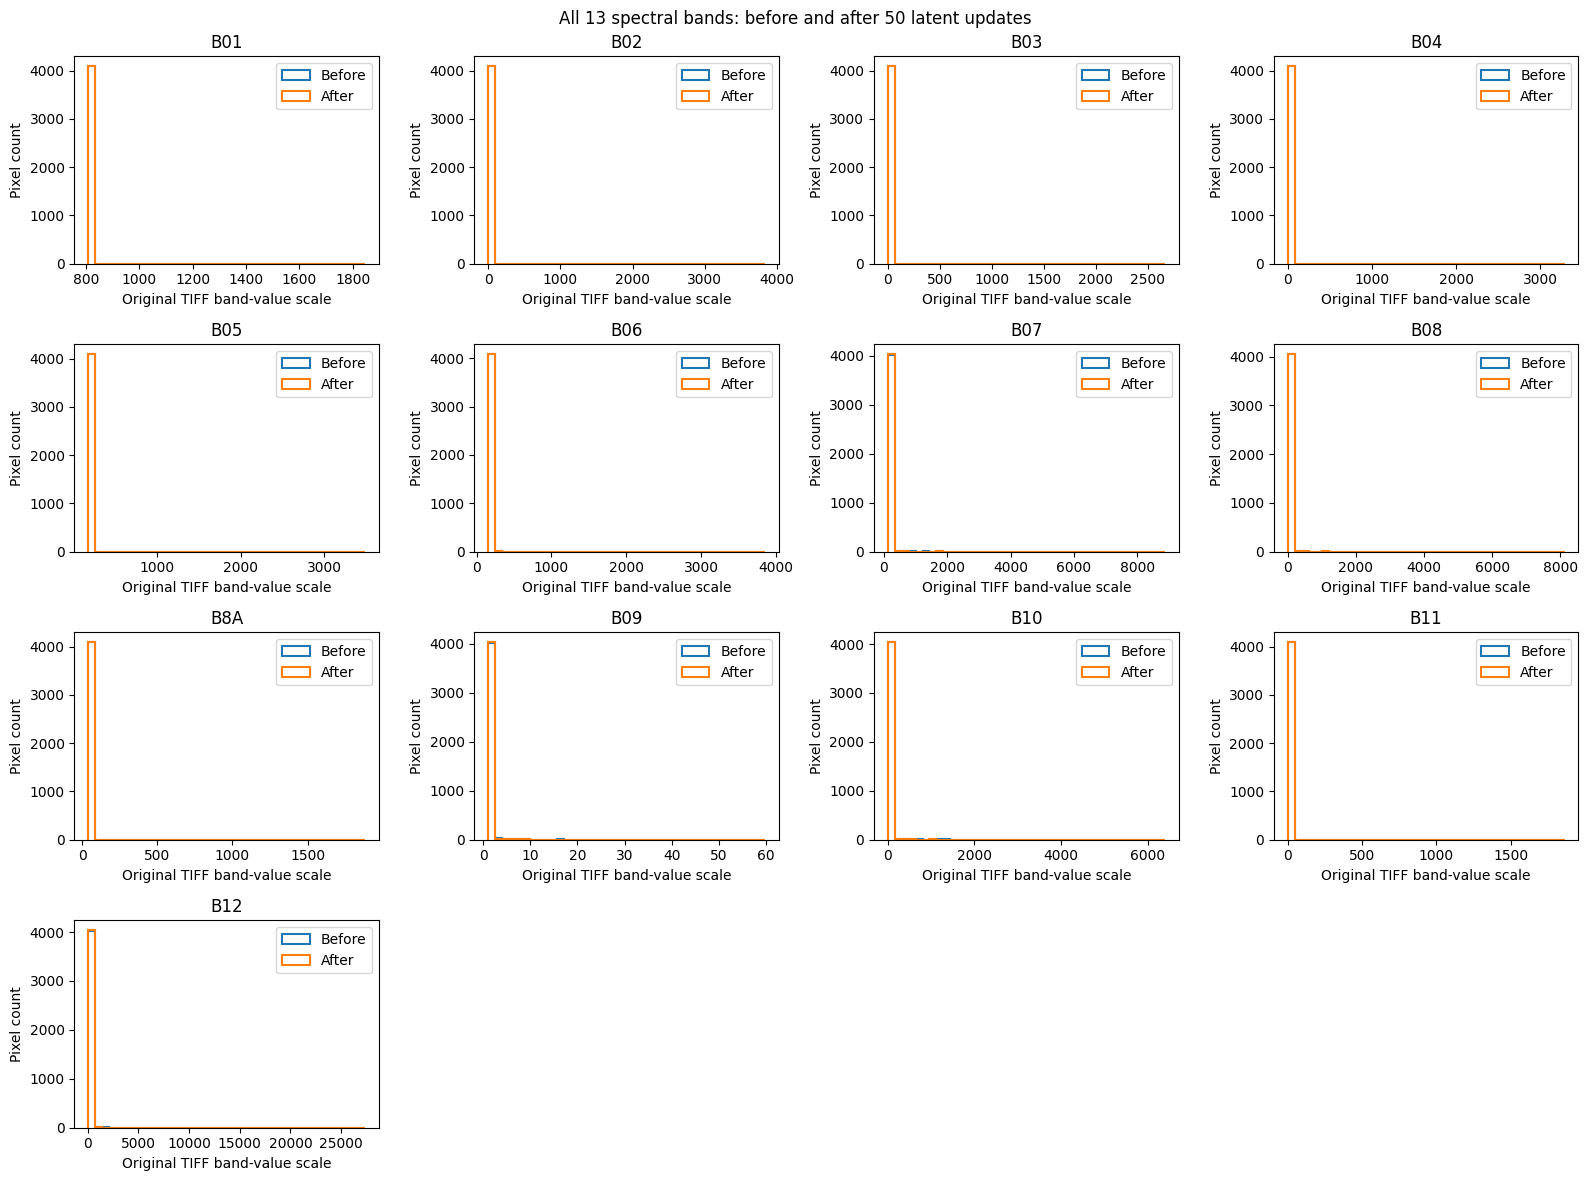

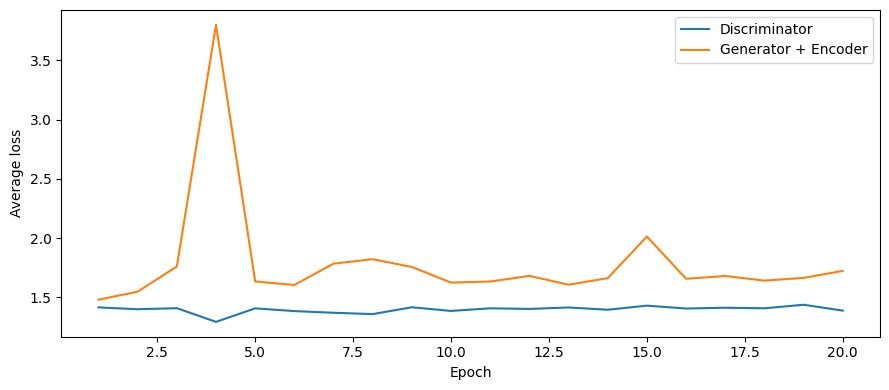

Saved outputs: /kaggle/working/q1_2_bigan_simple


In [2]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
import json
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt


SEED = 2026
DATA_ROOT = Path('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands')
OUTPUT_DIR = Path('/kaggle/working/q1_2_bigan_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
LEARNING_RATE = 0.0002
ATTACK_STEPS = 50
ATTACK_LEARNING_RATE = 0.1


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


def prepare_data():
    classes = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                      'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                      'River', 'SeaLake'])
    root, class_folders = find_dataset(
        DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', classes)
    train_files, validation_files = [], []
    rng = np.random.default_rng(SEED)

    # The guide uses a seeded 80/20 split within each class.
    for name in classes:
        files = sorted(p for p in class_folders[name].rglob('*')
                       if p.is_file() and p.suffix.lower() in ('.tif', '.tiff'))
        if len(files) < 2:
            raise ValueError(f'No usable TIFF class folder: {root / name}')
        order = rng.permutation(len(files))
        split = max(1, min(len(files) - 1, int(0.8 * len(files))))
        train_files.extend(files[i] for i in order[:split])
        validation_files.extend(files[i] for i in order[split:])
    train_files.sort()
    validation_files.sort()

    # Fit normalization using training images only, separately for each band.
    minimum = np.full(13, np.inf, dtype=np.float32)
    maximum = np.full(13, -np.inf, dtype=np.float32)
    for i, path in enumerate(train_files):
        image = read_image(path)
        minimum = np.minimum(minimum, image.min(axis=(1, 2)))
        maximum = np.maximum(maximum, image.max(axis=(1, 2)))
        if (i + 1) % 5000 == 0:
            print(f'Reading normalization values: {i + 1}/{len(train_files)}')
    if np.any(maximum <= minimum):
        raise ValueError('A band has no variation. Check the dataset.')
    print('Dataset:', root)
    print('Training images:', len(train_files), 'Validation images:', len(validation_files))
    return train_files, validation_files, minimum, maximum


class EuroSATDataset(Dataset):
    def __init__(self, files, minimum, maximum):
        self.files = files
        self.minimum = minimum[:, None, None]
        self.maximum = maximum[:, None, None]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = read_image(self.files[index])
        image = 2 * (image - self.minimum) / (self.maximum - self.minimum) - 1
        return torch.from_numpy(image)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z.reshape(-1, LATENT_DIM, 1, 1)))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))


def leaky_relu(x):
    return torch.where(x >= 0, x, 0.2 * x)


class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.latent = nn.Linear(128 * 8 * 8, LATENT_DIM)

    def forward(self, x):
        x = leaky_relu(self.conv1(x))
        x = leaky_relu(self.conv2(x))
        x = leaky_relu(self.conv3(x))
        return self.latent(x.flatten(1))


def broadcast_latent(x, z):
    # [B,128] -> [B,128,1,1] -> [B,128,64,64].
    assert z.shape == (x.shape[0], LATENT_DIM)
    z_image = z[:, :, None, None].expand(-1, -1, x.shape[2], x.shape[3])
    return torch.cat([x, z_image], dim=1)  # [B,141,64,64]


class JointDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13 + LATENT_DIM, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 1, 3, 1, 1)

    def forward(self, x, z):
        pair = broadcast_latent(x, z)
        h = leaky_relu(self.conv1(pair))
        h = leaky_relu(self.conv2(h))
        h = leaky_relu(self.conv3(h))
        return self.conv4(h).mean(dim=(1, 2, 3))  # One raw logit per joint pair.


def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        nn.init.zeros_(layer.bias)


def binary_loss(logits, target):
    # Stable binary cross entropy: log(1 + exp(logit)) - target * logit.
    return (torch.logaddexp(torch.zeros_like(logits), logits) - target * logits).mean()


def check_gradients(model):
    for parameter in model.parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise FloatingPointError('Missing or nonfinite gradient; training stopped.')


def latent_attack(generator, encoder, discriminator, device):
    for model in (generator, encoder, discriminator):
        model.eval()
        model.zero_grad(set_to_none=True)
        model.requires_grad_(False)

    # Dedicated RNG: the initial attack vector does not depend on training RNG consumption.
    attack_rng = torch.Generator(device=device).manual_seed(SEED)
    z_attack = torch.randn(1, LATENT_DIM, device=device, generator=attack_rng)
    z_initial = z_attack.detach().clone()
    z_attack.requires_grad_(True)
    with torch.no_grad():
        image_before = generator(z_attack).cpu().clone()
        probability_before = discriminator(generator(z_attack), z_attack).sigmoid().item()

    attack_log_probability = []
    assert ATTACK_STEPS == 50, 'Q1.2 requires exactly 50 updates.'
    for step in range(ATTACK_STEPS):
        generated = generator(z_attack)
        logit = discriminator(generated, z_attack)
        # Ascend log(sigmoid(D(G(z),z))) to make the generated pair look real.
        objective = -torch.logaddexp(torch.zeros_like(logit), -logit).mean()
        if not torch.isfinite(objective):
            raise FloatingPointError('Nonfinite latent attack objective.')
        gradient = torch.autograd.grad(objective, z_attack)[0]
        if not torch.isfinite(gradient).all():
            raise FloatingPointError('Nonfinite latent attack gradient.')
        attack_log_probability.append(objective.item())
        with torch.no_grad():
            z_attack.add_(ATTACK_LEARNING_RATE * gradient)  # Gradient ASCENT; only z changes.
        if not torch.isfinite(z_attack).all():
            raise FloatingPointError('Nonfinite attack latent.')

    z_final = z_attack.detach().clone()
    with torch.no_grad():
        image_after = generator(z_final).cpu().clone()
        final_logit = discriminator(generator(z_final), z_final)
        probability_after = final_logit.sigmoid().item()
        attack_log_probability.append(-torch.logaddexp(torch.zeros_like(final_logit), -final_logit).mean().item())
    # Float64 reduction of the actual saved float32 latent vectors.
    distance = (z_final.cpu().double() - z_initial.cpu().double()).square().sum().sqrt().item()
    if not np.isfinite(distance):
        raise FloatingPointError('Nonfinite latent displacement.')
    return dict(z_initial=z_initial.cpu(), z_final=z_final.cpu(),
                image_before=image_before, image_after=image_after,
                distance=distance, probability_before=probability_before,
                probability_after=probability_after, log_probability=attack_log_probability)


def plot_histograms(attack, minimum, maximum):
    # Convert generated values back to the original TIFF band-value scale.
    before = (attack['image_before'][0].numpy() + 1) / 2
    after = (attack['image_after'][0].numpy() + 1) / 2
    before = before * (maximum - minimum)[:, None, None] + minimum[:, None, None]
    after = after * (maximum - minimum)[:, None, None] + minimum[:, None, None]
    bands = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
             'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']
    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    for band, ax in enumerate(axes.flat):
        if band >= 13:
            ax.set_visible(False)
            continue
        low = min(before[band].min(), after[band].min())
        high = max(before[band].max(), after[band].max())
        if high <= low:
            high = low + 1
        bins = np.linspace(low, high, 41)  # Same bins before and after within a band.
        ax.hist(before[band].ravel(), bins=bins, histtype='step', label='Before', linewidth=1.5)
        ax.hist(after[band].ravel(), bins=bins, histtype='step', label='After', linewidth=1.5)
        ax.set(title=bands[band], xlabel='Original TIFF band-value scale', ylabel='Pixel count')
        ax.legend()
    fig.suptitle('All 13 spectral bands: before and after 50 latent updates')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'spectral_histograms_before_after.png', dpi=150)
    plt.show()


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # Identical preprocessing to Q1_1_FGAN.py for the same attached dataset.
    train_files, validation_files, minimum, maximum = prepare_data()
    train_data = EuroSATDataset(train_files, minimum, maximum)
    validation_data = EuroSATDataset(validation_files, minimum, maximum)
    if len(validation_data) <= 42:
        raise ValueError('The validation set must contain image index 42.')
    x_real = validation_data[42].unsqueeze(0)
    validation_info = dict(index=42, path=str(validation_files[42]),
                           class_name=validation_files[42].parent.name)
    print('Validation image 42:', validation_info)
    # The guide clarifies that x_real is recorded, not encoded or added to the attack loss.
    # The specified attacked pair is (G(z_attack), z_attack); no reconstruction target is used.
    loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                        generator=torch.Generator().manual_seed(SEED))
    generator = Generator().to(device)
    encoder = Encoder().to(device)
    discriminator = JointDiscriminator().to(device)
    for model in (generator, encoder, discriminator):
        model.apply(initialize_weights)
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optimizer_ge = torch.optim.Adam(list(generator.parameters()) + list(encoder.parameters()),
                                    lr=LEARNING_RATE, betas=(0.5, 0.999))
    noise_rng = torch.Generator(device=device).manual_seed(SEED)
    d_history, ge_history = [], []

    for epoch in range(EPOCHS):
        d_total, ge_total, count = 0.0, 0.0, 0
        for real in loader:
            real = real.to(device)
            batch_size = len(real)
            z = torch.randn(batch_size, LATENT_DIM, device=device, generator=noise_rng)

            # D: (real,E(real)) is real; (G(z),z) is fake.
            optimizer_d.zero_grad(set_to_none=True)
            with torch.no_grad():
                encoded = encoder(real)
                generated = generator(z)
            loss_d = (binary_loss(discriminator(real, encoded), 1.0)
                      + binary_loss(discriminator(generated, z), 0.0))
            if not torch.isfinite(loss_d):
                raise FloatingPointError('Nonfinite discriminator loss.')
            loss_d.backward()
            check_gradients(discriminator)
            optimizer_d.step()
            optimizer_d.zero_grad(set_to_none=True)

            # Guide-approved label-swapped loss: E and G try to fool the fixed D.
            discriminator.requires_grad_(False)
            try:
                optimizer_ge.zero_grad(set_to_none=True)
                z = torch.randn(batch_size, LATENT_DIM, device=device, generator=noise_rng)
                loss_ge = (binary_loss(discriminator(real, encoder(real)), 0.0)
                           + binary_loss(discriminator(generator(z), z), 1.0))
                if not torch.isfinite(loss_ge):
                    raise FloatingPointError('Nonfinite generator/encoder loss.')
                loss_ge.backward()
                check_gradients(generator)
                check_gradients(encoder)
                optimizer_ge.step()
            finally:
                discriminator.requires_grad_(True)
            d_total += loss_d.item() * batch_size
            ge_total += loss_ge.item() * batch_size
            count += batch_size
        d_history.append(d_total / count)
        ge_history.append(ge_total / count)
        print(f'Epoch {epoch + 1}/{EPOCHS}: D={d_history[-1]:.6f}, G+E={ge_history[-1]:.6f}')

    torch.save(dict(generator=generator.state_dict(), encoder=encoder.state_dict(),
                    discriminator=discriminator.state_dict(), seed=SEED, epochs=EPOCHS,
                    batch_size=BATCH_SIZE, latent_dim=LATENT_DIM, learning_rate=LEARNING_RATE,
                    minimum=torch.from_numpy(minimum), maximum=torch.from_numpy(maximum),
                    train_files=[str(p) for p in train_files], validation_files=[str(p) for p in validation_files],
                    discriminator_loss=d_history, generator_encoder_loss=ge_history),
               OUTPUT_DIR / 'bigan_model.pt')

    attack = latent_attack(generator, encoder, discriminator, device)
    torch.save(dict(**attack, x_real_index42=x_real, validation_info=validation_info,
                    attack_steps=ATTACK_STEPS, attack_learning_rate=ATTACK_LEARNING_RATE),
               OUTPUT_DIR / 'latent_attack.pt')
    results = dict(q1_2_zattack_l2_distance_50steps=attack['distance'],
                   probability_real_before=attack['probability_before'],
                   probability_real_after=attack['probability_after'],
                   attack_steps=ATTACK_STEPS, attack_learning_rate=ATTACK_LEARNING_RATE,
                   validation_image=validation_info)
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))
    print('Exact ||z_50 - z_0||_2:', repr(attack['distance']))
    print('D probability of real, before/after:', attack['probability_before'], attack['probability_after'])
    plot_histograms(attack, minimum, maximum)

    plt.figure(figsize=(9, 4))
    plt.plot(range(1, EPOCHS + 1), d_history, label='Discriminator')
    plt.plot(range(1, EPOCHS + 1), ge_history, label='Generator + Encoder')
    plt.xlabel('Epoch')
    plt.ylabel('Average loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_losses.png')
    plt.show()
    print('Saved outputs:', OUTPUT_DIR)


if __name__ == '__main__':
    main()


## Q1.3 — WGAN-GP

The critic minimizes

$$
L_D=\mathbb E[D(G(z))]-\mathbb E[D(x)]+\lambda\mathbb E[(\|\nabla_{\hat x}D(\hat x)\|_2-1)^2],\quad
\hat x=\epsilon x+(1-\epsilon)G(z).
$$

The generator minimizes $-\mathbb E[D(G(z))]$. This implementation forms the input gradient using `autograd.grad(..., create_graph=True)` so the penalty can train the critic.

In training-mode BatchNorm,

$$
y_i=\gamma\frac{h_i-\mu_B}{\sqrt{\sigma_B^2+\delta}}+\beta,
$$

where the batch mean and variance depend on all examples. Generally $\partial y_i/\partial h_j\ne0$ for $j\ne i$. Changing another sample can therefore change the score assigned to a fixed $x_i$: this is not the independent function $D(x)$ assumed by the per-sample Kantorovich–Rubinstein formulation. Also, the gain $|\gamma|/\sqrt{\sigma_B^2+\delta}$ is not bounded by one. BatchNorm does not enforce the required Lipschitz bound and invalidates the usual independent-sample gradient-penalty interpretation. It is not mathematically true that every possible BatchNorm parameter setting must violate a Lipschitz bound.

The critic here uses **no normalization**, with leaky-ReLU hidden activations and a linear scalar output. Gradient penalty encourages local unit gradient norms; it is not a proof of global 1-Lipschitzness. For the first training batch, every interpolation factor is fixed to 0.5 and the **unscaled** penalty is printed before its optimizer update.

Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Reading normalization values: 5000/22077
Reading normalization values: 10000/22077
Reading normalization values: 15000/22077
Reading normalization values: 20000/22077
Dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Training images: 22077 Validation images: 5520
Epoch 1 Batch 1, epsilon=0.5, UNSCALED gradient penalty: 0.9948620796203613
Epoch 1/20: critic=-128.270528, generator=-208.522268, GP=4.978252
Epoch 2/20: critic=-34.986698, generator=199.640323, GP=1.081839
Epoch 3/20: critic=-42.033277, generator=446.292247, GP=1.670081
Epoch 4/20: critic=-34.855104, generator=374.197609, GP=1.126221
Epoch 5/20: critic=-17.323024, generator=175.079638, GP=0.372572
Epoch 6/20: critic=-9.213640, generator=54.706674, GP=0.149950
Epoch 7/20: critic=-2.606560, generator=-7.002880, GP=0.036707
Epoch 8/20: critic=-3.710644, generator=1.758639, GP=0.045466
Epoch 9/20: 

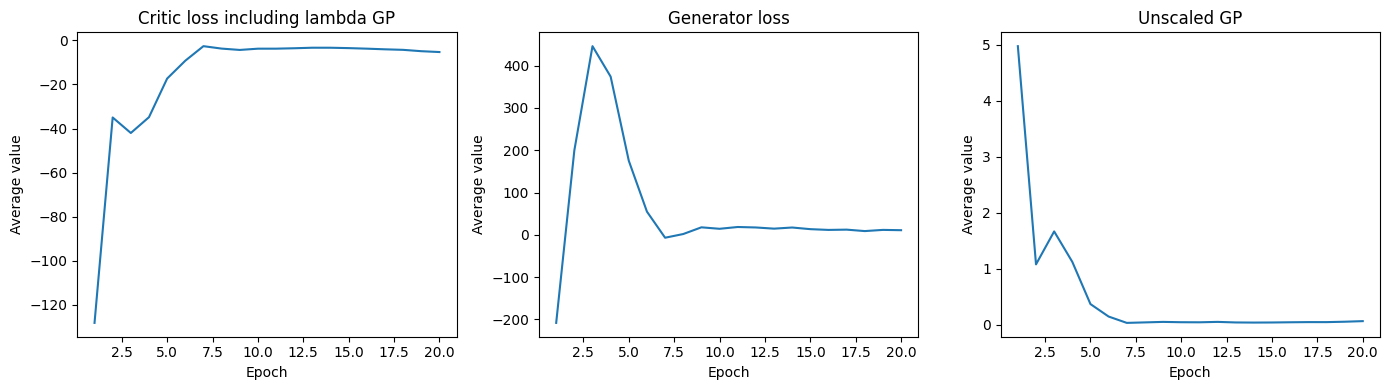

Required unscaled first-batch GP: 0.9948620796203613
Saved 13-band samples and models in: /kaggle/working/q1_3_wgan_gp_simple


In [3]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

import random
import json
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import matplotlib.pyplot as plt


SEED = 2026
DATA_ROOT = None  # Or Path('/kaggle/input/your-dataset/EuroSATAllBands')
OUTPUT_DIR = Path('/kaggle/working/q1_3_wgan_gp_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
LEARNING_RATE = 0.0001
GP_WEIGHT = 10.0
CRITIC_STEPS = 5


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


def prepare_data():
    classes = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                      'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                      'River', 'SeaLake'])
    root, class_folders = find_dataset(
        DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', classes)
    train_files, validation_files = [], []
    rng = np.random.default_rng(SEED)

    # The guide uses a seeded 80/20 split within each class.
    for name in classes:
        files = sorted(p for p in class_folders[name].rglob('*')
                       if p.is_file() and p.suffix.lower() in ('.tif', '.tiff'))
        if len(files) < 2:
            raise ValueError(f'No usable TIFF class folder: {root / name}')
        order = rng.permutation(len(files))
        split = max(1, min(len(files) - 1, int(0.8 * len(files))))
        train_files.extend(files[i] for i in order[:split])
        validation_files.extend(files[i] for i in order[split:])
    train_files.sort()
    validation_files.sort()

    # Fit normalization using training images only, separately for each band.
    minimum = np.full(13, np.inf, dtype=np.float32)
    maximum = np.full(13, -np.inf, dtype=np.float32)
    for i, path in enumerate(train_files):
        image = read_image(path)
        minimum = np.minimum(minimum, image.min(axis=(1, 2)))
        maximum = np.maximum(maximum, image.max(axis=(1, 2)))
        if (i + 1) % 5000 == 0:
            print(f'Reading normalization values: {i + 1}/{len(train_files)}')
    if np.any(maximum <= minimum):
        raise ValueError('A band has no variation. Check the dataset.')
    print('Dataset:', root)
    print('Training images:', len(train_files), 'Validation images:', len(validation_files))
    return train_files, validation_files, minimum, maximum


class EuroSATDataset(Dataset):
    def __init__(self, files, minimum, maximum):
        self.files = files
        self.minimum = minimum[:, None, None]
        self.maximum = maximum[:, None, None]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        image = read_image(self.files[index])
        image = 2 * (image - self.minimum) / (self.maximum - self.minimum) - 1
        return torch.from_numpy(image)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))


def leaky_relu(x):
    return torch.where(x >= 0, x, 0.2 * x)



class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 4, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 4, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 4, 2, 1)
        self.conv4 = nn.Conv2d(128, 1, 3, 1, 1)

    def forward(self, x):
        x = leaky_relu(self.conv1(x))
        x = leaky_relu(self.conv2(x))
        x = leaky_relu(self.conv3(x))
        return self.conv4(x).mean(dim=(1, 2, 3))  # One real score per image; no sigmoid.


def initialize_weights(layer):
    if isinstance(layer, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(layer.weight, 0.0, 0.02)
        nn.init.zeros_(layer.bias)


def gradient_penalty(critic, real, fake, epsilon):
    # x_hat = epsilon * real + (1-epsilon) * fake.
    # Detach the endpoints so this critic update cannot train the generator.
    # x_hat itself remains attached to the critic graph and requires input gradients.
    x_hat = epsilon * real.detach() + (1 - epsilon) * fake.detach()
    x_hat.requires_grad_(True)
    scores = critic(x_hat)
    gradients = torch.autograd.grad(outputs=scores, inputs=x_hat,
                                    grad_outputs=torch.ones_like(scores),
                                    create_graph=True)[0]
    norms = torch.linalg.vector_norm(gradients.flatten(1), ord=2, dim=1)
    gp = ((norms - 1) ** 2).mean()  # Unscaled: mean of squared differences, not square of mean.
    return gp, norms, x_hat


def check_gradients(model):
    for parameter in model.parameters():
        if parameter.grad is None or not torch.isfinite(parameter.grad).all():
            raise FloatingPointError('Missing or nonfinite gradient; training stopped.')


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # Same split and normalization as Q1_1_FGAN.py for identical input TIFF files.
    train_files, validation_files, minimum, maximum = prepare_data()
    dataset = EuroSATDataset(train_files, minimum, maximum)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                        generator=torch.Generator().manual_seed(SEED))
    generator = Generator().to(device)
    critic = Critic().to(device)
    generator.apply(initialize_weights)
    critic.apply(initialize_weights)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
    optimizer_c = torch.optim.Adam(critic.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
    noise_rng = torch.Generator(device=device).manual_seed(SEED)
    epsilon_rng = torch.Generator(device=device).manual_seed(SEED)
    first_gp = None
    history = []

    for epoch in range(1, EPOCHS + 1):
        critic_total, gp_total, generator_total = 0.0, 0.0, 0.0
        critic_examples, generator_examples = 0, 0
        for batch_number, real in enumerate(loader, start=1):
            real = real.to(device)
            batch_size = len(real)
            optimizer_c.zero_grad(set_to_none=True)
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
            with torch.no_grad():
                fake = generator(z)

            if epoch == 1 and batch_number == 1:
                epsilon = torch.full((batch_size, 1, 1, 1), 0.5, device=device)
            else:
                epsilon = torch.rand(batch_size, 1, 1, 1, device=device, generator=epsilon_rng)
            gp, norms, x_hat = gradient_penalty(critic, real, fake, epsilon)
            if not torch.isfinite(gp):
                raise FloatingPointError('Nonfinite gradient penalty.')

            if epoch == 1 and batch_number == 1:
                assert torch.all(epsilon == 0.5)
                first_gp = gp.item()  # Capture before any optimizer step; no lambda multiplier.
                torch.save(dict(unscaled_gp=first_gp, epsilon=epsilon.cpu(),
                                gradient_norms=norms.detach().cpu(),
                                interpolated_images=x_hat.detach().cpu()),
                           OUTPUT_DIR / 'first_batch_gp.pt')
                print('Epoch 1 Batch 1, epsilon=0.5, UNSCALED gradient penalty:', repr(first_gp))

            # Critic minimizes fake score - real score + lambda * GP.
            loss_c = critic(fake).mean() - critic(real).mean() + GP_WEIGHT * gp
            if not torch.isfinite(loss_c):
                raise FloatingPointError('Nonfinite critic loss.')
            loss_c.backward()
            check_gradients(critic)
            optimizer_c.step()
            optimizer_c.zero_grad(set_to_none=True)
            critic_total += loss_c.item() * batch_size
            gp_total += gp.item() * batch_size
            critic_examples += batch_size

            # Five fresh real minibatches per G update; finish a short group at epoch end.
            if batch_number % CRITIC_STEPS == 0 or batch_number == len(loader):
                critic.requires_grad_(False)
                try:
                    optimizer_g.zero_grad(set_to_none=True)
                    z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=noise_rng)
                    loss_g = -critic(generator(z)).mean()
                    if not torch.isfinite(loss_g):
                        raise FloatingPointError('Nonfinite generator loss.')
                    loss_g.backward()
                    check_gradients(generator)
                    optimizer_g.step()
                finally:
                    critic.requires_grad_(True)
                generator_total += loss_g.item() * batch_size
                generator_examples += batch_size

        row = dict(epoch=epoch, critic_loss=critic_total / critic_examples,
                   generator_loss=generator_total / generator_examples,
                   unscaled_gp=gp_total / critic_examples)
        history.append(row)
        print(f"Epoch {epoch}/{EPOCHS}: critic={row['critic_loss']:.6f}, "
              f"generator={row['generator_loss']:.6f}, GP={row['unscaled_gp']:.6f}")

    assert first_gp is not None
    results = dict(q1_3_gp_unscaled_e1_b1_eps_0_5=first_gp)
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))
    (OUTPUT_DIR / 'training_history.json').write_text(json.dumps(history, indent=2, allow_nan=False))
    torch.save(dict(generator=generator.state_dict(), critic=critic.state_dict(),
                    latent_dim=LATENT_DIM, seed=SEED, epochs=EPOCHS, batch_size=BATCH_SIZE,
                    learning_rate=LEARNING_RATE, gp_weight=GP_WEIGHT, critic_steps=CRITIC_STEPS,
                    minimum=torch.from_numpy(minimum), maximum=torch.from_numpy(maximum),
                    train_files=[str(p) for p in train_files], validation_files=[str(p) for p in validation_files],
                    results=results, history=history), OUTPUT_DIR / 'wgan_gp_model.pt')

    generator.eval()
    sample_rng = torch.Generator(device=device).manual_seed(SEED + 1)
    with torch.no_grad():
        z = torch.randn(8, LATENT_DIM, 1, 1, device=device, generator=sample_rng)
        generated = generator(z).cpu()
    assert generated.shape == (8, 13, 64, 64) and torch.isfinite(generated).all()
    torch.save(generated, OUTPUT_DIR / 'generated_13band_samples.pt')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key, title in zip(axes, ['critic_loss', 'generator_loss', 'unscaled_gp'],
                             ['Critic loss including lambda GP', 'Generator loss', 'Unscaled GP']):
        ax.plot([r['epoch'] for r in history], [r[key] for r in history])
        ax.set(title=title, xlabel='Epoch', ylabel='Average value')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
    plt.show()
    print('Required unscaled first-batch GP:', repr(first_gp))
    print('Saved 13-band samples and models in:', OUTPUT_DIR)


if __name__ == '__main__':
    main()

## Q1.4 — Custom Fréchet Feature Distance

A 13-channel classifier trained on EuroSAT training labels provides 128-dimensional embeddings. Freeze this classifier, then extract features for exactly 1,000 distinct validation images and 1,000 images from the Q1.3 generator. For a feature matrix $X$ with $n$ rows,

$$
\mu_X=\frac1n\sum_iX_i,\qquad \Sigma_X=\frac{(X-\mu_X)^T(X-\mu_X)}{n-1}.
$$

The metric is

$$
d^2=\|\mu_X-\mu_Y\|_2^2+\operatorname{Tr}(\Sigma_X+\Sigma_Y)-2\operatorname{Tr}[(\Sigma_X\Sigma_Y)^{1/2}].
$$

The covariance product is generally nonsymmetric. Instead use the equivalent square-root trace of the symmetric positive-semidefinite matrix $A=\Sigma_X^{1/2}\Sigma_Y\Sigma_X^{1/2}$. Symmetrize the covariances and use float64 eigendecompositions:

$$
\begin{aligned}
\Sigma_X &= U\operatorname{diag}(s)U^T, \\
\Sigma_X^{1/2} &= U\operatorname{diag}(\sqrt{s})U^T, \\
A &= \Sigma_X^{1/2}\Sigma_Y\Sigma_X^{1/2}, \\
\operatorname{Tr}(A^{1/2}) &= \sum_i \sqrt{\lambda_i(A)}.
\end{aligned}
$$

The implementation clamps negative eigenvalues only when they fall within the numerical roundoff tolerance and rejects materially invalid matrices. A self-comparison checks that the distance between the real features and themselves is approximately zero. The saved outputs report a real-feature covariance trace of **464.38800910188684** and an FFD of **285.21221834766965**.

Device: cuda
Found multispectral dataset: /kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands
Using trained generator: /kaggle/working/q1_3_wgan_gp_simple/wgan_gp_model.pt
Epoch 1/20: loss=1.8630, train accuracy=0.287, validation accuracy=0.359
Epoch 2/20: loss=1.5510, train accuracy=0.420, validation accuracy=0.485
Epoch 3/20: loss=1.4193, train accuracy=0.458, validation accuracy=0.492
Epoch 4/20: loss=1.2953, train accuracy=0.525, validation accuracy=0.620
Epoch 5/20: loss=1.1095, train accuracy=0.598, validation accuracy=0.614
Epoch 6/20: loss=1.0430, train accuracy=0.621, validation accuracy=0.654
Epoch 7/20: loss=0.9759, train accuracy=0.648, validation accuracy=0.671
Epoch 8/20: loss=0.9497, train accuracy=0.655, validation accuracy=0.697
Epoch 9/20: loss=0.9135, train accuracy=0.672, validation accuracy=0.696
Epoch 10/20: loss=0.8286, train accuracy=0.707, validation accuracy=0.688
Epoch 11/20: loss=0.7892, train accuracy=0.721, validation accuracy=0.723
Epoch 12/

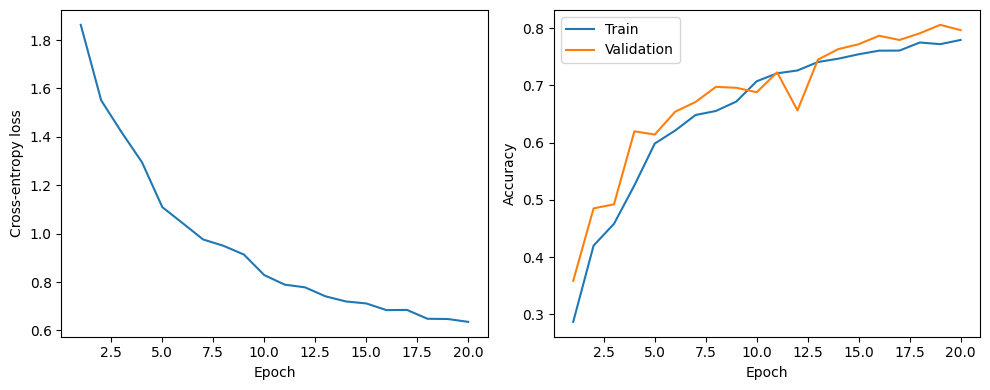

Saved outputs: /kaggle/working/q1_4_ffd_simple


In [4]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import random
import json
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
import rasterio
import matplotlib.pyplot as plt

SEED = 2026
DATA_ROOT = Path('/kaggle/input/datasets/apollo2506/eurosat-dataset/EuroSATallBands')
WGAN_CHECKPOINT = Path('/kaggle/working/q1_3_wgan_gp_simple/wgan_gp_model.pt')
OUTPUT_DIR = Path('/kaggle/working/q1_4_ffd_simple')
BATCH_SIZE = 64
EPOCHS = 20
LATENT_DIM = 128
FEATURE_DIM = 128
NUM_IMAGES = 1000
LEARNING_RATE = 0.001
CLASSES = sorted(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                  'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'])


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True)
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False


def read_image(path):
    with rasterio.open(path) as image:
        pixels = image.read(masked=True)
    if pixels.shape != (13, 64, 64):
        raise ValueError(f'{path}: expected 13 bands of size 64 x 64.')
    if np.ma.getmaskarray(pixels).any():
        raise ValueError(f'{path}: contains missing pixels.')
    pixels = np.asarray(pixels, dtype=np.float32)
    if not np.isfinite(pixels).all():
        raise ValueError(f'{path}: contains invalid pixel values.')
    return pixels


def find_dataset(search_root, classes):
    search_root = Path(search_root)
    if not search_root.is_dir():
        raise ValueError(f'Dataset directory does not exist: {search_root}')
    candidates, rejected, visited = [], [], set()
    required = {name.lower() for name in classes}

    # Find the class folders themselves, regardless of the enclosing folder's spelling.
    for directory, subfolders, _ in os.walk(search_root, followlinks=True):
        root = Path(directory)
        resolved = root.resolve()
        if resolved in visited:
            subfolders[:] = []
            continue
        visited.add(resolved)
        names = {name.lower(): name for name in subfolders}
        if not required.issubset(names):
            continue
        class_folders = {name: root / names[name.lower()] for name in classes}
        try:
            for folder in class_folders.values():
                sample = next((p for p in sorted(folder.rglob('*'))
                               if p.is_file() and p.suffix.lower() in ('.tif', '.tiff')), None)
                if sample is None:
                    raise ValueError(f'No TIFF images in {folder}')
                with rasterio.open(sample) as image:
                    if (image.count, image.height, image.width) != (13, 64, 64):
                        raise ValueError(f'{sample}: requires 13 bands, 64 x 64 pixels')
            candidates.append((root, class_folders))
        except (ValueError, rasterio.errors.RasterioIOError) as error:
            rejected.append(str(error))
        subfolders[:] = []

    if len(candidates) == 1:
        print('Found multispectral dataset:', candidates[0][0])
        return candidates[0]
    visible = [p.name for p in sorted(search_root.iterdir())][:20]
    raise ValueError(
        f'Found {len(candidates)} usable 13-band EuroSAT folders under {search_root}.\n'
        f'Candidates: {[str(root) for root, _ in candidates]}\n'
        f'Visible entries: {visible}\n'
        f'Rejected folders: {rejected[:5]}\n'
        'Attach the extracted EuroSATAllBands data. Set DATA_ROOT to its copied Kaggle '
        'directory path if needed; the folder may contain additional nesting.')


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.conv3 = nn.ConvTranspose2d(128, 64, 4, 2, 1)
        self.conv4 = nn.ConvTranspose2d(64, 32, 4, 2, 1)
        self.conv5 = nn.ConvTranspose2d(32, 13, 4, 2, 1)

    def forward(self, z):
        x = torch.relu(self.conv1(z))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = torch.relu(self.conv4(x))
        return torch.tanh(self.conv5(x))

def load_wgan_data():
    checkpoint_path = WGAN_CHECKPOINT
    if not checkpoint_path.is_file():
        matches = sorted(Path('/kaggle/input').rglob('wgan_gp_model.pt'))
        if len(matches) != 1:
            raise FileNotFoundError('Run Q1_3_WGAN_GP.py first, or attach its wgan_gp_model.pt '
                                    f'and set WGAN_CHECKPOINT. Found: {matches}')
        checkpoint_path = matches[0]
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    required = ['generator', 'minimum', 'maximum', 'train_files', 'validation_files', 'latent_dim']
    if not all(key in checkpoint for key in required):
        raise ValueError('Use wgan_gp_model.pt produced by Q1_3_WGAN_GP.py.')
    if checkpoint['latent_dim'] != LATENT_DIM:
        raise ValueError('LATENT_DIM must match the trained Q1.3 generator.')
    _, class_folders = find_dataset(DATA_ROOT if DATA_ROOT is not None else '/kaggle/input', CLASSES)

    # Reuse Q1.3's exact split, even if Kaggle mounted this dataset under a new path.
    def restore_files(saved_paths):
        restored = []
        for saved in saved_paths:
            parts = str(saved).replace('\\', '/').split('/')
            hits = [(i, name) for i, part in enumerate(parts) for name in CLASSES
                    if part.lower() == name.lower()]
            if len(hits) != 1:
                raise ValueError(f'Cannot identify the EuroSAT class in saved path: {saved}')
            index, name = hits[0]
            path = class_folders[name].joinpath(*parts[index + 1:])
            if not path.is_file():
                raise FileNotFoundError(f'Q1.3 image missing from attached data: {path}')
            restored.append((path, CLASSES.index(name)))
        return restored

    train_records = restore_files(checkpoint['train_files'])
    val_records = restore_files(checkpoint['validation_files'])
    train_paths = {p for p, _ in train_records}
    val_paths = {p for p, _ in val_records}
    assert len(train_paths) == len(train_records) and len(val_paths) == len(val_records)
    assert not train_paths.intersection(val_paths), 'Training and validation sets overlap.'
    if len(val_records) < NUM_IMAGES:
        raise ValueError('Q1.4 needs at least 1,000 distinct real validation images.')
    minimum = checkpoint['minimum'].numpy().astype(np.float32)
    maximum = checkpoint['maximum'].numpy().astype(np.float32)
    if (minimum.shape != (13,) or maximum.shape != (13,) or
            not np.isfinite(minimum).all() or not np.isfinite(maximum).all() or
            not np.all(maximum > minimum)):
        raise ValueError('Invalid saved normalization statistics.')
    print('Using trained generator:', checkpoint_path)
    return checkpoint, checkpoint_path, train_records, val_records, minimum, maximum


class EuroSATClassifierDataset(Dataset):
    def __init__(self, records, minimum, maximum):
        self.records = records
        self.minimum = minimum[:, None, None]
        self.span = (maximum - minimum)[:, None, None]
    def __len__(self):
        return len(self.records)
    def __getitem__(self, index):
        path, label = self.records[index]
        image = 2 * (read_image(path) - self.minimum) / self.span - 1
        return torch.from_numpy(image), label


class FeatureClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(13, 32, 3, 2, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 2, 1)
        self.conv3 = nn.Conv2d(64, 128, 3, 2, 1)
        self.embedding = nn.Linear(128, FEATURE_DIM)
        self.classifier = nn.Linear(FEATURE_DIM, len(CLASSES))
    def extract_features(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))
        x = x.mean(dim=(2, 3))
        return torch.relu(self.embedding(x))  # Dense 128-dimensional representation.
    def forward(self, x):
        return self.classifier(self.extract_features(x))  # Ten logits only for training.


def classification_loss(logits, labels):
    correct_logits = logits.gather(1, labels[:, None]).squeeze(1)
    return (torch.logsumexp(logits, dim=1) - correct_logits).mean()


def feature_statistics(features):
    features = features.detach().cpu().double()
    if features.ndim != 2 or len(features) < 2 or not torch.isfinite(features).all():
        raise ValueError('Expected a finite [number_of_images, feature_dimension] matrix.')
    mean = features.mean(0)
    centered = features - mean
    covariance = centered.T @ centered / (len(features) - 1)  # Unbiased sample covariance.
    return mean, (covariance + covariance.T) / 2


def psd_eigendecomposition(matrix):
    matrix = matrix.detach().cpu().double()
    if not torch.isfinite(matrix).all():
        raise ValueError('Nonfinite covariance matrix.')
    matrix = (matrix + matrix.T) / 2
    values, vectors = torch.linalg.eigh(matrix)
    scale = max(values.abs().max().item(), torch.finfo(torch.float64).eps)
    tolerance = 100 * matrix.shape[0] * torch.finfo(torch.float64).eps * scale
    if values.min().item() < -tolerance:
        raise ValueError('Substantially negative covariance eigenvalue; inspect the statistics.')
    return values.clamp_min(0), vectors  # Clamp only negatives within roundoff tolerance.


def frechet_distance(mean_x, covariance_x, mean_y, covariance_y):
    # FFD = ||mu_X-mu_Y||^2 + Tr(Sigma_X)+Tr(Sigma_Y)-2*Tr(sqrt(Sigma_X*Sigma_Y)).
    # The product need not be symmetric. Its square-root trace equals the trace of
    # sqrt(sqrt(Sigma_X) @ Sigma_Y @ sqrt(Sigma_X)), a symmetric PSD matrix.
    # Use float64 eigendecomposition, not elementwise sqrt or complex-value truncation.
    mean_x, mean_y = mean_x.cpu().double(), mean_y.cpu().double()
    covariance_x, covariance_y = covariance_x.cpu().double(), covariance_y.cpu().double()
    values, vectors = psd_eigendecomposition(covariance_x)
    psd_eigendecomposition(covariance_y)  # Reject a materially invalid covariance.
    sqrt_x = (vectors * values.sqrt().unsqueeze(0)) @ vectors.T
    middle = sqrt_x @ covariance_y @ sqrt_x
    middle_values, _ = psd_eigendecomposition(middle)
    mean_term = (mean_x - mean_y).square().sum()
    trace_term = covariance_x.trace() + covariance_y.trace()
    distance = mean_term + trace_term - 2 * middle_values.sqrt().sum()
    # Rank-deficient matrix square roots amplify roundoff near zero eigenvalues.
    tolerance = 1e-6 * max(1.0, abs(trace_term.item()), mean_term.item())
    if not torch.isfinite(distance) or distance.item() < -tolerance:
        raise ValueError('Invalid FFD; numerical error is too large.')
    return max(0.0, distance.item())  # Remove a tiny negative final cancellation only.


def main():
    set_seed()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)
    assert NUM_IMAGES == 1000, 'Q1.4 requires exactly 1,000 images in each group.'
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    checkpoint, checkpoint_path, train_records, val_records, minimum, maximum = load_wgan_data()
    train_data = EuroSATClassifierDataset(train_records, minimum, maximum)
    val_data = EuroSATClassifierDataset(val_records, minimum, maximum)
    train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                              generator=torch.Generator().manual_seed(SEED))
    val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                            generator=torch.Generator().manual_seed(SEED))
    generator = Generator().to(device)
    generator.load_state_dict(checkpoint['generator'], strict=True)
    generator.eval()
    generator.requires_grad_(False)
    classifier = FeatureClassifier().to(device)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
    history = []
    for epoch in range(1, EPOCHS + 1):
        classifier.train()
        total_loss, correct = 0.0, 0
        for x, labels in train_loader:
            x, labels = x.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = classifier(x)
            loss = classification_loss(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError('Nonfinite classifier loss.')
            loss.backward()
            for parameter in classifier.parameters():
                if parameter.grad is None or not torch.isfinite(parameter.grad).all():
                    raise FloatingPointError('Missing or nonfinite classifier gradient.')
            optimizer.step()
            total_loss += loss.item() * len(x)
            correct += (logits.argmax(1) == labels).sum().item()
        classifier.eval()
        val_correct = 0
        with torch.no_grad():
            for x, labels in val_loader:
                val_correct += (classifier(x.to(device)).argmax(1).cpu() == labels).sum().item()
        row = dict(epoch=epoch, train_loss=total_loss / len(train_data),
                   train_accuracy=correct / len(train_data), validation_accuracy=val_correct / len(val_data))
        history.append(row)
        print(f"Epoch {epoch}/{EPOCHS}: loss={row['train_loss']:.4f}, "
              f"train accuracy={row['train_accuracy']:.3f}, validation accuracy={row['validation_accuracy']:.3f}")

    classifier.requires_grad_(False)
    classifier.eval()
    # Seeded subset spreads selection across the sorted validation list instead of taking
    # its first 1,000 files, which could be dominated by the alphabetically first classes.
    selection_rng = np.random.default_rng(SEED)
    indices = selection_rng.choice(len(val_data), size=NUM_IMAGES, replace=False).tolist()
    real_loader = DataLoader(Subset(val_data, indices), batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=0, generator=torch.Generator().manual_seed(SEED))
    real_features, fake_features, sampled_latents = [], [], []
    latent_rng = torch.Generator(device=device).manual_seed(SEED)
    with torch.no_grad():
        for x, _ in real_loader:
            real_features.append(classifier.extract_features(x.to(device)).cpu().double())
        for start in range(0, NUM_IMAGES, BATCH_SIZE):
            batch_size = min(BATCH_SIZE, NUM_IMAGES - start)  # Last batch is 40 when B=64.
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device, generator=latent_rng)
            fake = generator(z)
            fake_features.append(classifier.extract_features(fake).cpu().double())
            sampled_latents.append(z.cpu())
    real_features = torch.cat(real_features)
    fake_features = torch.cat(fake_features)
    assert real_features.shape == fake_features.shape == (1000, FEATURE_DIM)
    mean_x, covariance_x = feature_statistics(real_features)
    mean_y, covariance_y = feature_statistics(fake_features)
    self_distance = frechet_distance(mean_x, covariance_x, mean_x, covariance_x)
    assert self_distance < 1e-6 * max(1.0, covariance_x.trace().item()), 'FFD self-check failed.'
    ffd = frechet_distance(mean_x, covariance_x, mean_y, covariance_y)
    results = dict(q1_4_real_cov_trace=covariance_x.trace().item(), q1_4_ffd=ffd,
                   real_count=1000, generated_count=1000, self_comparison_ffd=self_distance)
    print('Exact real covariance trace:', repr(results['q1_4_real_cov_trace']))
    print('Final WGAN-GP FFD:', repr(ffd))
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))
    torch.save(dict(real_embeddings=real_features, generated_embeddings=fake_features,
                    real_mean=mean_x, generated_mean=mean_y, real_covariance=covariance_x,
                    generated_covariance=covariance_y, latent_vectors=torch.cat(sampled_latents),
                    real_indices=indices, real_files=[str(val_records[i][0]) for i in indices],
                    covariance_denominator=999, results=results), OUTPUT_DIR / 'ffd_statistics.pt')
    torch.save(dict(classifier=classifier.state_dict(), classes=CLASSES, feature_dim=FEATURE_DIM,
                    minimum=torch.from_numpy(minimum), maximum=torch.from_numpy(maximum),
                    seed=SEED, epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
                    generator_checkpoint=str(checkpoint_path), history=history),
               OUTPUT_DIR / 'feature_classifier.pt')
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot([r['epoch'] for r in history], [r['train_loss'] for r in history])
    axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss')
    axes[1].plot([r['epoch'] for r in history], [r['train_accuracy'] for r in history], label='Train')
    axes[1].plot([r['epoch'] for r in history], [r['validation_accuracy'] for r in history], label='Validation')
    axes[1].set(xlabel='Epoch', ylabel='Accuracy')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'classifier_training.png', dpi=150)
    plt.show()
    print('Saved outputs:', OUTPUT_DIR)


if __name__ == '__main__':
    main()


## Q2.1 — Cyclical beta-VAE

The encoder produces $\mu(x)$ and $\log\sigma^2(x)$, with reparameterization $z=\mu+\sigma\odot\varepsilon$, $\varepsilon\sim\mathcal N(0,I)$. The per-coordinate divergence is

$$
\mathrm{KL}_j=\tfrac12(\mu_j^2+\sigma_j^2-1-\log\sigma_j^2).
$$

Use $L=\frac12\mathbb E\|x-\hat x\|_2^2+\beta\mathbb E\sum_j\mathrm{KL}_j$. For one-based epoch $e$,

$$
\beta_e=\frac{(e-1)\bmod10}{9},\qquad e=1,\ldots,50.
$$

This gives five cycles with endpoints exactly 0 and 1. A dimension is active if its mean validation KL exceeds 0.1. Plot the active count and beta together.

At the end of epochs 10 and 11, log the sampled latent vectors of validation sample 100 (index 99). A fixed, separately seeded noise vector is reused for these two probes to avoid confounding model change with independent sampling noise. The reported statistic is $z_{10}^Tz_{11}/(\|z_{10}\|\|z_{11}\|)$, not cosine similarity of the posterior means.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.8 MB/s eta 0:00:00
Device: cpu | Data folder: /kaggle/working/ADRL_q2_outputs/mitdb
Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list 

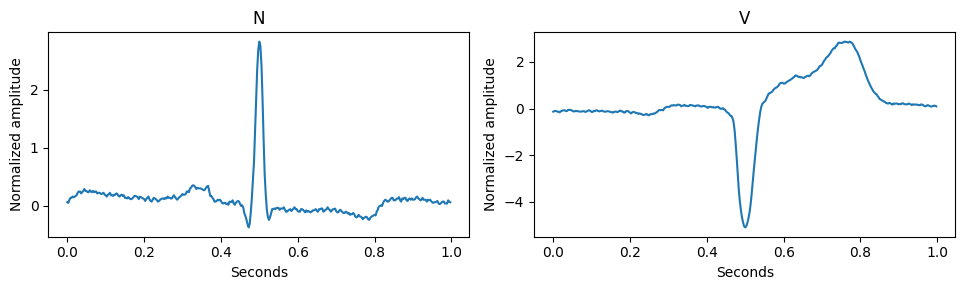

VAE epoch 01: beta=0.000, active=16, loss=94.5572
VAE epoch 02: beta=0.111, active=16, loss=14.8443
VAE epoch 03: beta=0.222, active=16, loss=13.7930
VAE epoch 04: beta=0.333, active=16, loss=15.2158
VAE epoch 05: beta=0.444, active=16, loss=16.7101
VAE epoch 06: beta=0.556, active=16, loss=17.9353
VAE epoch 07: beta=0.667, active=16, loss=18.8867
VAE epoch 08: beta=0.778, active=16, loss=19.6340
VAE epoch 09: beta=0.889, active=15, loss=20.1889
VAE epoch 10: beta=1.000, active=15, loss=20.9091
VAE epoch 11: beta=0.000, active=16, loss=2.9617
VAE epoch 12: beta=0.111, active=16, loss=6.2135
VAE epoch 13: beta=0.222, active=16, loss=8.9203
VAE epoch 14: beta=0.333, active=16, loss=10.5137
VAE epoch 15: beta=0.444, active=16, loss=12.2011
VAE epoch 16: beta=0.556, active=16, loss=13.6434
VAE epoch 17: beta=0.667, active=16, loss=14.9946
VAE epoch 18: beta=0.778, active=16, loss=16.0975
VAE epoch 19: beta=0.889, active=15, loss=17.1790
VAE epoch 20: beta=1.000, active=15, loss=18.1137
VAE

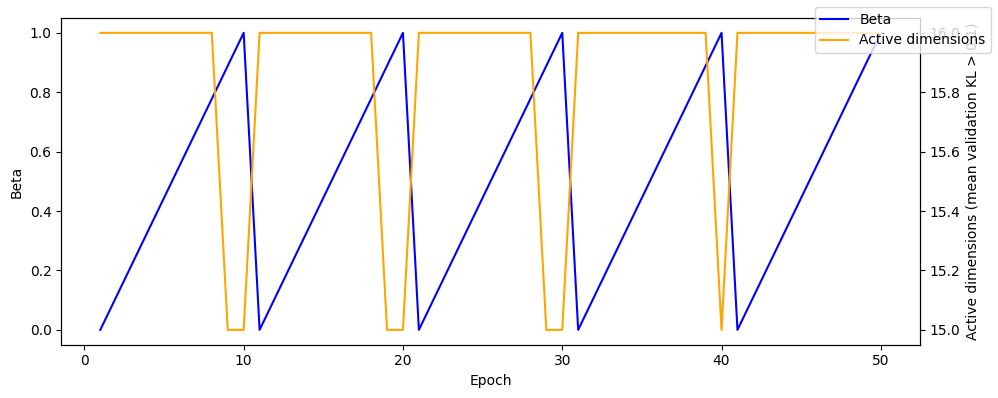

In [1]:
# Q2.1 - Cyclical beta-VAE. Run all four cells in order in Kaggle or VS Code.
# Select a Python kernel with: pip install torch numpy matplotlib wfdb ipykernel
# Papers: https://arxiv.org/abs/1312.6114
# https://openreview.net/forum?id=Sy2fzU9gl ; https://aclanthology.org/N19-1021/
# Both supplied PDFs define the task; small layer widths are implementation choices.
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import random
import json
from pathlib import Path
import sys
import subprocess
try:
    import wfdb
except ImportError:
    # Kaggle needs Internet enabled for this one-time dependency installation.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'wfdb'])
    import wfdb

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 2026
def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
set_seed()
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
# Use an extracted raw MIT-BIH dataset with .hea, .dat and .atr files.
# Set DATA_DIR explicitly if you attach more than one copy of the dataset.
DATA_DIR = None
ON_KAGGLE = Path('/kaggle/input').is_dir()
OUTPUT_DIR = (Path('/kaggle/working') if ON_KAGGLE else Path.cwd()) / 'ADRL_q2_outputs'
DOWNLOAD_DATA = True  # If no raw records are found, download MIT-BIH from PhysioNet.
if DATA_DIR is None:
    search_root = Path('/kaggle/input') if ON_KAGGLE else Path.cwd() / 'data' / 'mitdb'
    candidates = {}
    for header in search_root.rglob('*.hea'):
        if (header.stem.isdigit() and header.with_suffix('.dat').exists()
                and header.with_suffix('.atr').exists()):
            candidates[header.parent] = candidates.get(header.parent, 0) + 1
    folders = sorted(folder for folder, count in candidates.items() if count >= 5)
    if len(folders) > 1:
        raise ValueError(f'Multiple raw datasets found. Set DATA_DIR to one of: {folders}')
    DATA_DIR = folders[0] if folders else OUTPUT_DIR / 'mitdb'
DATA_DIR = Path(DATA_DIR)
BATCH_SIZE = 128
LATENT_DIM = 16
VAE_EPOCHS = 50  # Required: five cycles of ten epochs.
VQ_EPOCHS = 20
STARGAN_EPOCHS = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', device, '| Data folder:', DATA_DIR)

record_paths = sorted(p.with_suffix('') for p in DATA_DIR.rglob('*.hea')
                      if p.with_suffix('.atr').exists() and p.with_suffix('.dat').exists())
if not record_paths and DOWNLOAD_DATA:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print('Downloading MIT-BIH from PhysioNet; this needs internet access.')
    wfdb.dl_database('mitdb', dl_dir=str(DATA_DIR))
    record_paths = sorted(p.with_suffix('') for p in DATA_DIR.rglob('*.hea')
                          if p.with_suffix('.atr').exists() and p.with_suffix('.dat').exists())
if len(record_paths) < 5:
    raise ValueError('Attach/extract raw MIT-BIH .hea/.dat/.atr files and set DATA_DIR, or set DOWNLOAD_DATA=True with Internet enabled.')

# Split whole records so beats from a record do not enter both sets.
rng = np.random.default_rng(SEED)
order = rng.permutation(len(record_paths))
cut = int(0.8 * len(record_paths))
train_records = sorted(record_paths[i] for i in order[:cut])
val_records = sorted(record_paths[i] for i in order[cut:])

def read_beats(records):
    beats, labels, metadata = [], [], []
    for path in records:
        record = wfdb.rdrecord(str(path))
        annotation = wfdb.rdann(str(path), 'atr')
        if record.fs != 360:
            raise ValueError(f'{path}: expected a 360 Hz MIT-BIH recording.')
        channel = record.sig_name.index('MLII') if 'MLII' in record.sig_name else 0
        signal = record.p_signal[:, channel]
        for location, symbol in zip(annotation.sample, annotation.symbol):
            if symbol not in ('N', 'V') or location < 180 or location + 180 > len(signal):
                continue
            beat = signal[location - 180:location + 180].astype(np.float32)
            if not np.isfinite(beat).all():
                raise ValueError(f'{path}: nonfinite ECG window.')
            beats.append(beat)
            labels.append(0 if symbol == 'N' else 1)
            metadata.append(dict(record=path.name, sample=int(location),
                                 label=symbol, channel=record.sig_name[channel]))
    if not beats:
        raise ValueError('No N/V beats found in these records.')
    # Define the order BEFORE training: N first, then V; record and time within each class.
    # This makes the literal validation index 150 an N when enough N beats exist.
    indices = sorted(range(len(beats)), key=lambda i: (labels[i], metadata[i]['record'], metadata[i]['sample']))
    return (np.stack([beats[i] for i in indices]), np.array([labels[i] for i in indices]),
            [metadata[i] for i in indices])

train_x, train_y, train_meta = read_beats(train_records)
val_x, val_y, val_meta = read_beats(val_records)
mean_train = float(train_x.astype(np.float64).mean())
std_train = float(train_x.astype(np.float64).std())
if std_train <= 0:
    raise ValueError('Training ECG has zero variance.')
train_x = ((train_x - mean_train) / std_train).astype(np.float32)
val_x = ((val_x - mean_train) / std_train).astype(np.float32)

class ECGDataset(Dataset):
    def __init__(self, signals, labels):
        self.signals = torch.from_numpy(signals).unsqueeze(1)
        self.labels = torch.from_numpy(labels).long()
    def __len__(self):
        return len(self.signals)
    def __getitem__(self, index):
        return self.signals[index], self.labels[index]

train_data = ECGDataset(train_x, train_y)
val_data = ECGDataset(val_x, val_y)
assert len(val_data) > 150 and val_y[150] == 0, 'Need at least 151 N validation beats.'
assert set(train_y.tolist()) == {0, 1} and set(val_y.tolist()) == {0, 1}
def make_train_loader():
    return DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=device.type == 'cuda',
                      generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=device.type == 'cuda',
                        generator=torch.Generator().manual_seed(SEED))
audit = dict(seed=SEED, train_mean=mean_train, train_std=std_train,
             train_records=[str(p) for p in train_records], val_records=[str(p) for p in val_records],
             validation_order='label, record, annotation sample', validation_metadata=val_meta,
             sample_100=val_meta[99], index_150=val_meta[150], torch_version=torch.__version__,
             device=str(device), gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else None)
(OUTPUT_DIR / 'data_audit.json').write_text(json.dumps(audit, indent=2))
print('Train/validation:', len(train_data), len(val_data))
print('100th sample:', val_meta[99], '| index 150:', val_meta[150])
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for label, ax in enumerate(axes):
    index = int(np.flatnonzero(train_y == label)[0])
    ax.plot(np.arange(360) / 360, train_x[index])
    ax.set(title=['N', 'V'][label], xlabel='Seconds', ylabel='Normalized amplitude')
plt.tight_layout()
plt.show()

results = {}
def save_results():
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))

def take_step(loss, optimizer, model):
    if not torch.isfinite(loss).item():
        raise FloatingPointError('Nonfinite loss; training stopped.')
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    parameters = [p for p in model.parameters() if p.requires_grad]
    if any(p.grad is None for p in parameters):
        raise FloatingPointError('Missing gradient.')
    if not torch.stack([torch.isfinite(p.grad).all() for p in parameters]).all().item():
        raise FloatingPointError('Nonfinite gradient.')
    optimizer.step()

class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv1d(1, 16, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(16, 32, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(32, 64, 4, 2, 1), nn.ReLU())
        self.mu = nn.Linear(64 * 45, LATENT_DIM)
        self.logvar = nn.Linear(64 * 45, LATENT_DIM)
        self.expand = nn.Linear(LATENT_DIM, 64 * 45)
        self.decoder = nn.Sequential(nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(32, 16, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(16, 1, 4, 2, 1))
    def encode(self, x):
        hidden = self.encoder(x).flatten(1)
        return self.mu(hidden), self.logvar(hidden)
    def decode(self, z):
        return self.decoder(self.expand(z).reshape(-1, 64, 45))
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

def kl_per_dimension(mu, logvar):
    return 0.5 * (mu.square() + logvar.exp() - 1 - logvar)

set_seed()
vae = VAE().to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)
train_loader = make_train_loader()
probe_epsilon = torch.randn(1, LATENT_DIM, generator=torch.Generator().manual_seed(SEED)).to(device)
probe_x = val_data[99][0].unsqueeze(0).to(device)
beta_history, active_history, vae_losses = [], [], []
probe_latents = {}
assert VAE_EPOCHS == 50
for epoch in range(1, VAE_EPOCHS + 1):
    beta = ((epoch - 1) % 10) / 9
    vae.train()
    total = 0.0
    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)
        reconstructed, mu, logvar = vae(x)
        # Gaussian reconstruction (unit variance): half summed squared error per beat.
        reconstruction_loss = 0.5 * (reconstructed - x).square().sum(dim=(1, 2)).mean()
        kl_loss = kl_per_dimension(mu, logvar).sum(dim=1).mean()
        loss = reconstruction_loss + beta * kl_loss
        take_step(loss, optimizer, vae)
        total += loss.item() * len(x)
    vae.eval()
    kl_sum = torch.zeros(LATENT_DIM, dtype=torch.float64)
    with torch.no_grad():
        for x, _ in val_loader:
            mu, logvar = vae.encode(x.to(device, non_blocking=True))
            kl_sum += kl_per_dimension(mu, logvar).double().cpu().sum(0)
        active = int((kl_sum / len(val_data) > 0.1).sum())
        if epoch in (10, 11):
            mu, logvar = vae.encode(probe_x)
            probe_latents[epoch] = (mu + torch.exp(0.5 * logvar) * probe_epsilon).cpu().clone()
    beta_history.append(beta)
    active_history.append(active)
    vae_losses.append(total / len(train_data))
    print(f'VAE epoch {epoch:02d}: beta={beta:.3f}, active={active}, loss={vae_losses[-1]:.4f}')

z10, z11 = probe_latents[10].double().flatten(), probe_latents[11].double().flatten()
denominator = z10.square().sum().sqrt() * z11.square().sum().sqrt()
if denominator.item() == 0:
    raise ValueError('Cosine similarity is undefined for a zero latent vector.')
results['q2_1_cosine_similarity'] = ((z10 * z11).sum() / denominator).item()
torch.save(dict(model=vae.state_dict(), z_epoch10=probe_latents[10], z_epoch11=probe_latents[11],
                probe_epsilon=probe_epsilon.cpu(), beta=beta_history, active=active_history,
                loss=vae_losses), OUTPUT_DIR / 'q2_1_vae.pt')
save_results()
print('Q2.1 cosine similarity:', repr(results['q2_1_cosine_similarity']))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, 51), beta_history, color='blue', label='Beta')
ax.set(xlabel='Epoch', ylabel='Beta')
other = ax.twinx()
other.plot(range(1, 51), active_history, color='orange', label='Active dimensions')
other.set_ylabel('Active dimensions (mean validation KL > 0.1)')
fig.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'q2_1_beta_activity.png')
plt.show()

q21_complete = True


## Q2.2 — Latent traversal

The validation posterior means $\mu(x_i)$ are used as deterministic latent embeddings. For coordinate $j$,

$$
\bar\mu_j=\frac1n\sum_i\mu_j(x_i),\qquad
s_j^2=\frac1n\sum_i(\mu_j(x_i)-\bar\mu_j)^2.
$$

Choose $j^*=\arg\max_j s_j^2$ and let $\sigma=\sqrt{s_{j^*}^2}$. Fix all other coordinates to their empirical means, including every inactive coordinate, and sweep the selected coordinate through

$$
z_{j^*}\in\{-3\sigma,-2\sigma,-\sigma,0,\sigma,2\sigma,3\sigma\}.
$$

This follows the existing implementation's sweep about zero, rather than a sweep about the empirical mean. The saved results select **coordinate 0**, with variance **0.9790308768067651**; this coordinate also passes the mean-KL threshold of 0.1.

**Interpretation of the grid wording.** The question specifies seven values of one coordinate but asks for a 7×7 grid without defining a second varying quantity. Seven settings give seven distinct decoded waveforms. The saved implementation creates a 7×7 canvas and displays those seven waveforms in its first row; the remaining axes are hidden. We retain the seven-step interpretation and the original figure. This explains the discrepancy but does not turn the saved figure into 49 populated plots. Producing 49 meaningful panels would require an additional choice, such as seven baseline latent vectors, followed by new decoding and plotting. No such computation or code change is made here.

Q2.2 dimension: 0 | variance: 0.9790308768067651
Selected dimension passes KL > 0.1: True


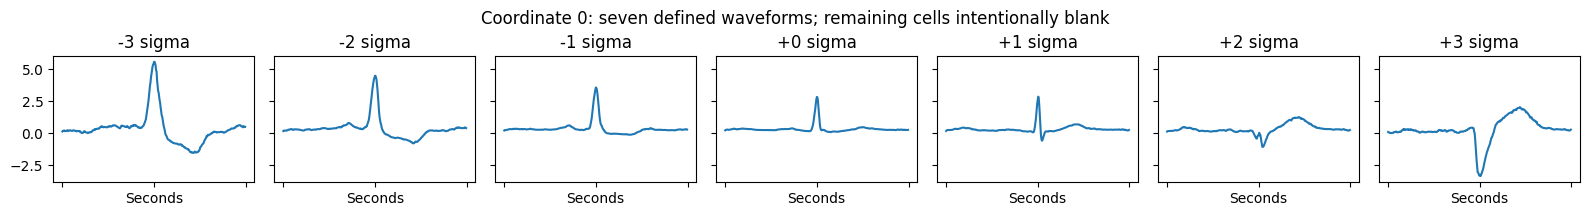

Peak-to-peak amplitudes: [7.095873832702637, 5.263965606689453, 3.6772499084472656, 2.7396926879882812, 3.4273226261138916, 2.329420566558838, 5.35367488861084]
Peak locations (sample indices): [181, 180, 180, 180, 181, 259, 259]
Inspect changes in height, timing and width. These measurements alone do not establish a physiological meaning.


In [2]:
# Run cell 1 first. This cell analyzes its trained VAE.
assert globals().get('q21_complete', False), 'Run cell 1 to completion first.'
# Q2.2 - Latent traversal. Reuse the trained VAE from cell 1; no new model training.
# Source: beta-VAE, https://openreview.net/forum?id=Sy2fzU9gl, and GUIDE.pdf.
vae.eval()
vae.requires_grad_(False)
all_means, all_kl = [], []
with torch.no_grad():
    for x, _ in val_loader:
        mu, logvar = vae.encode(x.to(device, non_blocking=True))
        all_means.append(mu.double().cpu())
        all_kl.append(kl_per_dimension(mu, logvar).double().cpu())
embeddings = torch.cat(all_means)
latent_mean = embeddings.mean(0)
latent_variance = (embeddings - latent_mean).square().mean(0)  # Divide by N.
active_mask = torch.cat(all_kl).mean(0) > 0.1
dimension = int(latent_variance.argmax())
sigma = latent_variance[dimension].sqrt()
sweep = torch.arange(-3, 4, dtype=torch.float64) * sigma
z = latent_mean.repeat(7, 1)  # Fix every other dimension, including inactive ones.
z[:, dimension] = sweep  # Exactly -3 sigma to +3 sigma, not mean +/- 3 sigma.
with torch.no_grad():
    waveforms = vae.decode(z.float().to(device)).cpu()
results['q2_2_max_variance_dim_index'] = dimension
results['q2_2_max_variance_value'] = latent_variance[dimension].item()
save_results()
torch.save(dict(variance=latent_variance, mean=latent_mean, active_mask=active_mask,
                sweep=sweep, z=z, waveforms=waveforms), OUTPUT_DIR / 'q2_2_traversal.pt')
print('Q2.2 dimension:', dimension, '| variance:', repr(latent_variance[dimension].item()))
print('Selected dimension passes KL > 0.1:', bool(active_mask[dimension]))

# The PDFs specify seven waveforms AND a 7x7 canvas. Follow the guide: first row only.
fig, axes = plt.subplots(7, 7, figsize=(16, 12), sharex=True, sharey=True)
for ax in axes.flat:
    ax.set_visible(False)
for i in range(7):
    ax = axes[0, i]
    ax.set_visible(True)
    ax.plot(np.arange(360) / 360, waveforms[i, 0].numpy())
    ax.set_title(f'{i - 3:+d} sigma')
    ax.set_xlabel('Seconds')
fig.suptitle(f'Coordinate {dimension}: seven defined waveforms; remaining cells intentionally blank')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'q2_2_traversal.png')
plt.show()
amplitude_range = waveforms[:, 0].amax(1) - waveforms[:, 0].amin(1)
print('Peak-to-peak amplitudes:', amplitude_range.tolist())
print('Peak locations (sample indices):', waveforms[:, 0].argmax(1).tolist())
print('Inspect changes in height, timing and width. These measurements alone do not establish a physiological meaning.')
# Add your observation after looking at the actual plot; no morphology is assumed in advance.
MORPHOLOGY_OBSERVATION = ''
if MORPHOLOGY_OBSERVATION:
    (OUTPUT_DIR / 'q2_2_observation.txt').write_text(MORPHOLOGY_OBSERVATION)


### Observation from the saved ECG waveforms

At $-3\sigma$, the waveform has a tall positive central peak and a later negative dip. As the coordinate moves toward zero, that positive peak becomes smaller and the later dip becomes less pronounced. Toward $+2\sigma$ and $+3\sigma$, the central deflection becomes negative, while a broader positive hump appears later in the waveform. The peak-to-peak amplitude also changes non-monotonically across the sweep.

The selected dimension therefore influences central-peak amplitude and polarity as well as the later waveform shape. Several features change together, so these plots do not establish a single independently controlled physiological characteristic. In particular, polarity changes alone are not evidence of a specific arrhythmia. This observation is based on the seven saved waveforms above; no additional waveforms have been generated.

## Q2.3 — Spherical VQ-VAE

Normalize encoder outputs $h_i$ to $\bar h_i=h_i/\|h_i\|_2$. With unit code vectors $e_k$, cosine lookup selects

$$
a_i=\arg\max_k\bar h_i^Te_k.
$$

For assignments $A_k=\{i:a_i=k\}$ and decay $\rho=0.99$, update running counts and sums:

$$
n_k\leftarrow\rho n_k+(1-\rho)|A_k|,\qquad
m_k\leftarrow\rho m_k+(1-\rho)\sum_{i\in A_k}\bar h_i.
$$

Then form $c_k=m_k/(n_k+\delta)$ and project onto the unit sphere:

$$
e_k\leftarrow c_k/\|c_k\|_2.
$$

A deterministic unit-vector fallback handles zero norm. Thus every stored code has norm one. After 100 consecutive unassigned updates, restart a code using a randomly selected normalized encoder output from the current batch and reset its EMA statistics.

Code vectors are non-parameter buffers, updated only under `no_grad` by EMA; **no straight-through gradient reaches the codebook**. The expression $\bar h+\operatorname{stopgrad}(e_a-\bar h)$ passes reconstruction gradients to the encoder only. Train the decoder/encoder with reconstruction loss plus a commitment penalty. At the end of the first epoch, compute $C_{ij}=e_i^Te_j$ and report $\max_{i\ne j}C_{ij}$. A maximum near one indicates a similar pair; by itself it does not prove that the entire codebook has collapsed or is diverse.

In [3]:
assert globals().get('q21_complete', False), 'Run cell 1 to completion first.'
# Q2.3 - Spherical VQ-VAE.
# Paper: https://arxiv.org/abs/1711.00937, sections 3.1-3.2 and Appendix A.1.
# Cosine lookup and unit-sphere EMA are assignment modifications to the original VQ-VAE.
# GUIDE interpretation: STE sends gradients to the ENCODER only. The codebook is a buffer.

def unit_vectors(x):
    norm = torch.linalg.vector_norm(x, dim=-1, keepdim=True)
    fallback = torch.zeros_like(x)
    fallback[..., 0] = 1
    return torch.where(norm > 1e-8, x / norm.clamp_min(1e-8), fallback)

class SphericalVQVAE(nn.Module):
    def __init__(self, code_count=64, code_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(nn.Conv1d(1, 16, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(16, 32, 4, 2, 1), nn.ReLU(),
                                     nn.Conv1d(32, code_dim, 4, 2, 1))
        self.decoder = nn.Sequential(nn.ConvTranspose1d(code_dim, 32, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(32, 16, 4, 2, 1), nn.ReLU(),
                                     nn.ConvTranspose1d(16, 1, 4, 2, 1))
        codes = unit_vectors(torch.randn(code_count, code_dim))
        self.register_buffer('codebook', codes)
        self.register_buffer('ema_count', torch.ones(code_count))
        self.register_buffer('ema_sum', codes.clone())
        self.register_buffer('unused_steps', torch.zeros(code_count, dtype=torch.long))
        self.decay = 0.99
        self.patience = 100

    def forward(self, x):
        encoded = self.encoder(x).transpose(1, 2)  # [B,45,32]
        normalized = unit_vectors(encoded)
        flat = normalized.reshape(-1, normalized.shape[-1])
        similarities = flat @ self.codebook.T
        indices = similarities.argmax(dim=1)
        quantized = self.codebook[indices].reshape_as(normalized)
        commitment = (normalized - quantized.detach()).square().mean()
        # Forward value is the selected code; backward derivative goes only to normalized.
        encoder_path = normalized + (quantized - normalized).detach()
        reconstructed = self.decoder(encoder_path.transpose(1, 2))
        return reconstructed, commitment, flat.detach(), indices.detach()

    @torch.no_grad()
    def update_codebook(self, flat, indices):
        assignments = (indices[:, None] == torch.arange(len(self.codebook), device=indices.device)).float()
        counts = assignments.sum(0)
        sums = assignments.T @ flat
        self.ema_count.mul_(self.decay).add_(counts, alpha=1 - self.decay)
        self.ema_sum.mul_(self.decay).add_(sums, alpha=1 - self.decay)
        centroids = self.ema_sum / (self.ema_count[:, None] + 1e-8)
        self.codebook.copy_(unit_vectors(centroids))
        self.unused_steps.add_(1)
        self.unused_steps[counts > 0] = 0
        dead = self.unused_steps >= self.patience
        if dead.any():
            selected = torch.randint(len(flat), (int(dead.sum()),), device=flat.device)
            replacements = unit_vectors(flat[selected])
            self.codebook[dead] = replacements
            self.ema_count[dead] = 1
            self.ema_sum[dead] = replacements
            self.unused_steps[dead] = 0
        assert torch.allclose(self.codebook.square().sum(1), torch.ones_like(self.ema_count), atol=1e-5)

set_seed()
vqvae = SphericalVQVAE().to(device)
optimizer_vq = torch.optim.Adam(vqvae.parameters(), lr=0.001)
assert 'codebook' not in dict(vqvae.named_parameters())
vq_loader = make_train_loader()
vq_history = []
for epoch in range(1, VQ_EPOCHS + 1):
    vqvae.train()
    total = 0.0
    for x, _ in vq_loader:
        x = x.to(device, non_blocking=True)
        reconstructed, commitment, flat, indices = vqvae(x)
        reconstruction_loss = (reconstructed - x).square().mean()
        loss = reconstruction_loss + 0.25 * commitment
        take_step(loss, optimizer_vq, vqvae)
        vqvae.update_codebook(flat, indices)  # No optimizer gradient updates these vectors.
        total += loss.item() * len(x)
    vq_history.append(total / len(train_data))
    if epoch == 1:
        codes = unit_vectors(vqvae.codebook.detach().cpu().double())
        cosine_matrix = codes @ codes.T
        off_diagonal = ~torch.eye(len(codes), dtype=torch.bool)
        maximum_cosine = cosine_matrix[off_diagonal].max().item()
        results['q2_3_max_offdiag_cosine_epoch1'] = maximum_cosine
        torch.save(dict(codebook=codes, cosine_matrix=cosine_matrix), OUTPUT_DIR / 'q2_3_epoch1_codes.pt')
        save_results()
        print('Q2.3 epoch-1 maximum off-diagonal cosine:', repr(maximum_cosine))
    print(f'VQ-VAE epoch {epoch}: loss={vq_history[-1]:.6f}')
torch.save(dict(model=vqvae.state_dict(), losses=vq_history), OUTPUT_DIR / 'q2_3_vqvae.pt')

Q2.3 epoch-1 maximum off-diagonal cosine: 0.9968832157217792
VQ-VAE epoch 1: loss=0.141559
VQ-VAE epoch 2: loss=0.026539
VQ-VAE epoch 3: loss=0.022973
VQ-VAE epoch 4: loss=0.024352
VQ-VAE epoch 5: loss=0.020918
VQ-VAE epoch 6: loss=0.019079
VQ-VAE epoch 7: loss=0.022252
VQ-VAE epoch 8: loss=0.019995
VQ-VAE epoch 9: loss=0.019385
VQ-VAE epoch 10: loss=0.019819
VQ-VAE epoch 11: loss=0.019778
VQ-VAE epoch 12: loss=0.019909
VQ-VAE epoch 13: loss=0.020444
VQ-VAE epoch 14: loss=0.022134
VQ-VAE epoch 15: loss=0.020787
VQ-VAE epoch 16: loss=0.021302
VQ-VAE epoch 17: loss=0.022223
VQ-VAE epoch 18: loss=0.021883
VQ-VAE epoch 19: loss=0.021268
VQ-VAE epoch 20: loss=0.022549


## Q2.4 — StarGAN-1D

Use exactly one generator and one discriminator. Concatenate the target's broadcast one-hot label with the input signal. The discriminator predicts real/fake and domain logits. With source $c_s$ and target $c_t$,

$$
L_{\mathrm{cls}}^r=\mathbb E[-\log p_D(c_s|x)],\quad
L_{\mathrm{cls}}^f=\mathbb E[-\log p_D(c_t|G(x,c_t))],
$$

$$
L_{\mathrm{cyc}}=\mathbb E\|G(G(x,c_t),c_s)-x\|_1.
$$

Add real classification loss to the discriminator's logistic adversarial loss; add fake classification and $10L_{\mathrm{cyc}}$ to the generator loss. Plot the same signal through N → V → N. Report the literal maximum (not maximum absolute amplitude) of the generated V waveform from validation index 150, in normalized units, with its conversion to the original signal units also printed.

StarGAN epoch 1: D=1.5629, G=3.9821
StarGAN epoch 2: D=1.4372, G=3.5108
StarGAN epoch 3: D=1.4401, G=3.4450
StarGAN epoch 4: D=1.3957, G=3.4192
StarGAN epoch 5: D=1.3619, G=3.4333
StarGAN epoch 6: D=1.3253, G=3.4277
StarGAN epoch 7: D=1.2596, G=3.3898
StarGAN epoch 8: D=1.2002, G=3.3751
StarGAN epoch 9: D=1.1711, G=3.3960
StarGAN epoch 10: D=1.1444, G=3.3895
StarGAN epoch 11: D=1.1252, G=3.3842
StarGAN epoch 12: D=1.1078, G=3.3949
StarGAN epoch 13: D=1.0855, G=3.3638
StarGAN epoch 14: D=1.0704, G=3.2990
StarGAN epoch 15: D=1.0500, G=3.2830
StarGAN epoch 16: D=1.0189, G=3.2558
StarGAN epoch 17: D=0.9905, G=3.2376
StarGAN epoch 18: D=0.9817, G=3.2495
StarGAN epoch 19: D=0.9759, G=3.2590
StarGAN epoch 20: D=0.9678, G=3.2610


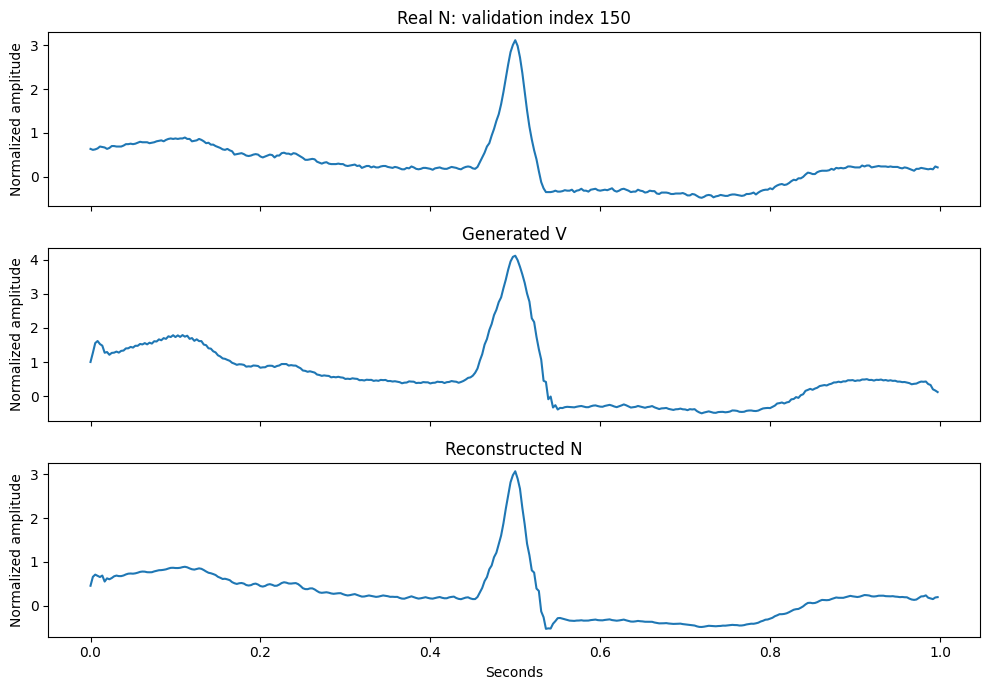

Q2.4 maximum amplitude (normalized units): 4.110568523406982
The same maximum in original signal units: 1.5339494828098736
{
  "q2_1_cosine_similarity": 0.8071993089835765,
  "q2_2_max_variance_dim_index": 0,
  "q2_2_max_variance_value": 0.9790308768067651,
  "q2_3_max_offdiag_cosine_epoch1": 0.9968832157217792,
  "q2_4_generated_v_max_amplitude_val150": 4.110568523406982
}
Saved results in: /kaggle/working/ADRL_q2_outputs


In [4]:
assert globals().get('q21_complete', False), 'Run cell 1 to completion first.'
# Q2.4 - StarGAN-1D: exactly one generator and one discriminator for both directions.
# Paper: https://arxiv.org/abs/1711.09020, section 3.1.
# Follow the GUIDE's simple logistic/BCE objective; not the paper's WGAN-GP experiments.
# lambda_cls=1 and lambda_cycle=10; linear waveform output because inputs are standardized.

class StarGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Conv1d(3, 32, 7, padding=3), nn.ReLU(),
                                 nn.Conv1d(32, 64, 4, 2, 1), nn.ReLU(),
                                 nn.Conv1d(64, 64, 3, padding=1), nn.ReLU(),
                                 nn.ConvTranspose1d(64, 32, 4, 2, 1), nn.ReLU(),
                                 nn.Conv1d(32, 1, 7, padding=3))
    def forward(self, x, target):
        one_hot = (target[:, None] == torch.arange(2, device=x.device)).float()
        labels = one_hot[:, :, None].expand(-1, -1, x.shape[-1])
        return self.net(torch.cat([x, labels], dim=1))

class StarDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv1d(1, 16, 4, 2, 1), nn.LeakyReLU(0.2),
                                      nn.Conv1d(16, 32, 4, 2, 1), nn.LeakyReLU(0.2),
                                      nn.Conv1d(32, 64, 4, 2, 1), nn.LeakyReLU(0.2))
        self.source = nn.Linear(64, 1)
        self.domain = nn.Linear(64, 2)
    def forward(self, x):
        features = self.features(x).mean(dim=2)
        return self.source(features).squeeze(1), self.domain(features)

def binary_loss(logits, targets):
    # Stable BCE with logits: log(1+exp(logit)) - target*logit.
    return (torch.logaddexp(torch.zeros_like(logits), logits) - targets * logits).mean()

def classification_loss(logits, labels):
    correct_logits = logits.gather(1, labels[:, None]).squeeze(1)
    return (torch.logsumexp(logits, dim=1) - correct_logits).mean()

set_seed()
star_g = StarGenerator().to(device)
star_d = StarDiscriminator().to(device)
optimizer_g = torch.optim.Adam(star_g.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_d = torch.optim.Adam(star_d.parameters(), lr=0.0002, betas=(0.5, 0.999))
star_loader = make_train_loader()
star_history = []
for epoch in range(1, STARGAN_EPOCHS + 1):
    star_g.train()
    star_d.train()
    total_d, total_g = 0.0, 0.0
    for x, source in star_loader:
        x, source = x.to(device, non_blocking=True), source.to(device)
        target = 1 - source
        with torch.no_grad():
            fake = star_g(x, target)
        real_logits, real_domains = star_d(x)
        fake_logits, _ = star_d(fake)
        loss_d = (binary_loss(real_logits, torch.ones_like(real_logits))
                  + binary_loss(fake_logits, torch.zeros_like(fake_logits))
                  + classification_loss(real_domains, source))
        take_step(loss_d, optimizer_d, star_d)
        optimizer_d.zero_grad(set_to_none=True)

        star_d.requires_grad_(False)
        try:
            fake = star_g(x, target)
            fake_logits, fake_domains = star_d(fake)
            reconstructed = star_g(fake, source)
            cycle_loss = (reconstructed - x).abs().mean()
            loss_g = (binary_loss(fake_logits, torch.ones_like(fake_logits))
                      + classification_loss(fake_domains, target) + 10 * cycle_loss)
            take_step(loss_g, optimizer_g, star_g)
        finally:
            star_d.requires_grad_(True)
        total_d += loss_d.item() * len(x)
        total_g += loss_g.item() * len(x)
    star_history.append([total_d / len(train_data), total_g / len(train_data)])
    print(f'StarGAN epoch {epoch}: D={star_history[-1][0]:.4f}, G={star_history[-1][1]:.4f}')

star_g.eval()
star_d.eval()
star_g.requires_grad_(False)
star_d.requires_grad_(False)
normal, label = val_data[150]  # Literal index 150 in the frozen validation order.
assert int(label) == 0, 'Validation index 150 must be N; do not substitute another sample.'
with torch.no_grad():
    normal = normal.unsqueeze(0).to(device)
    generated_v = star_g(normal, torch.ones(1, dtype=torch.long, device=device))
    reconstructed_n = star_g(generated_v, torch.zeros(1, dtype=torch.long, device=device))
maximum = generated_v.max().item()  # Literal maximum, not absolute maximum.
results['q2_4_generated_v_max_amplitude_val150'] = maximum
save_results()
torch.save(dict(generator=star_g.state_dict(), discriminator=star_d.state_dict(),
                normal=normal.cpu(), generated_v=generated_v.cpu(), reconstructed_n=reconstructed_n.cpu(),
                validation_metadata=val_meta[150], losses=star_history), OUTPUT_DIR / 'q2_4_stargan.pt')
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, signal, title in zip(axes, [normal, generated_v, reconstructed_n],
                             ['Real N: validation index 150', 'Generated V', 'Reconstructed N']):
    ax.plot(np.arange(360) / 360, signal[0, 0].cpu().numpy())
    ax.set(title=title, ylabel='Normalized amplitude')
axes[-1].set_xlabel('Seconds')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'q2_4_N_V_N.png')
plt.show()
print('Q2.4 maximum amplitude (normalized units):', repr(maximum))
print('The same maximum in original signal units:', repr(maximum * std_train + mean_train))
required = ['q2_1_cosine_similarity', 'q2_2_max_variance_dim_index', 'q2_2_max_variance_value',
            'q2_3_max_offdiag_cosine_epoch1', 'q2_4_generated_v_max_amplitude_val150']
assert all(key in results and np.isfinite(results[key]) for key in required)
print(json.dumps(results, indent=2))
print('Saved results in:', OUTPUT_DIR)


## Q3.1 — ModelNet40 Sinkhorn autoencoder

Following the dataset replacement announcement, each ModelNet40 mesh is converted into a set of 256 surface points. Triangles are sampled in proportion to their area, and points are sampled uniformly within each selected triangle. A stable per-mesh seed makes sampling repeatable. Each cloud is centered at its centroid and scaled to unit maximum radius. The dataset's train/test folders are kept separate.

For an unordered cloud $X\in\mathbb R^{N\times3}$, the encoder applies a shared pointwise MLP and symmetric max pooling:

$$
E(X)=\psi\left(\max_i\phi(x_i)\right).
$$

Permuting the input points only permutes the features before pooling, so $E(\Pi X)=E(X)$. Pointwise MSE would depend on arbitrary row correspondence, so reconstruction instead uses a transport plan.

Define $C_{ij}=\|x_i-y_j\|_2^2$ and uniform marginals $a_i=b_i=1/N$. Entropy-regularized transport solves

$$
P^*=\arg\min_{P\ge0,\;P\mathbf1=a,\;P^T\mathbf1=b}
\langle P,C\rangle+\varepsilon\sum_{ij}P_{ij}(\log P_{ij}-1).
$$

On the positive interior, the Hessian of the entropy term is $\varepsilon\operatorname{diag}(1/P_{ij})$, which is strictly positive. For finite costs, positive marginals and $\varepsilon>0$, this gives a unique positive optimum. Removing one redundant marginal constraint makes the constrained KKT system nonsingular, so the implicit-function theorem gives smooth dependence of $P^*$ on $C$. Unregularized optimal transport can instead switch its optimal matching abruptly.

Stationarity gives $P=\operatorname{diag}(u)K\operatorname{diag}(v)$ with $K_{ij}=\exp(-C_{ij}/\varepsilon)$. Sinkhorn-Knopp alternates

$$
u\leftarrow a/(Kv),\qquad v\leftarrow b/(K^Tu).
$$

The code implements these operations in the log domain with vectorized `logsumexp`, avoiding kernel underflow. One iteration comprises both updates. The finite unrolled operations remain differentiable, and only the copy saved for verification is detached.

**Loss used in this implementation:** after 30 iterations, the reconstruction loss is $\langle P_{30},C\rangle$, the transport cost evaluated using the entropy-regularized plan. The entropy contribution is used to determine the plan, but is not explicitly added to the scalar training loss. This is distinct from reporting the full regularized objective above. Gradients still propagate through the plan and cost.

After exactly five iterations of epoch 1, batch 1, the first row sum of the first sample's plan is **0.003906250931322575**. The target marginal is $1/256=0.00390625$. Its agreement checks this particular row; it does not by itself establish convergence of every marginal. The saved 3D overlay compares the original object cloud with its reconstruction.

Device: cuda | Dataset: /kaggle/input/datasets/balraj98/modelnet40-princeton-3d-object-dataset/ModelNet40
train: sampled 500/9843 meshes
train: sampled 1000/9843 meshes
train: sampled 1500/9843 meshes
train: sampled 2000/9843 meshes
train: sampled 2500/9843 meshes
train: sampled 3000/9843 meshes
train: sampled 3500/9843 meshes
train: sampled 4000/9843 meshes
train: sampled 4500/9843 meshes
train: sampled 5000/9843 meshes
train: sampled 5500/9843 meshes
train: sampled 6000/9843 meshes
train: sampled 6500/9843 meshes
train: sampled 7000/9843 meshes
train: sampled 7500/9843 meshes
train: sampled 8000/9843 meshes
train: sampled 8500/9843 meshes
train: sampled 9000/9843 meshes
train: sampled 9500/9843 meshes
test: sampled 500/2468 meshes
test: sampled 1000/2468 meshes
test: sampled 1500/2468 meshes
test: sampled 2000/2468 meshes


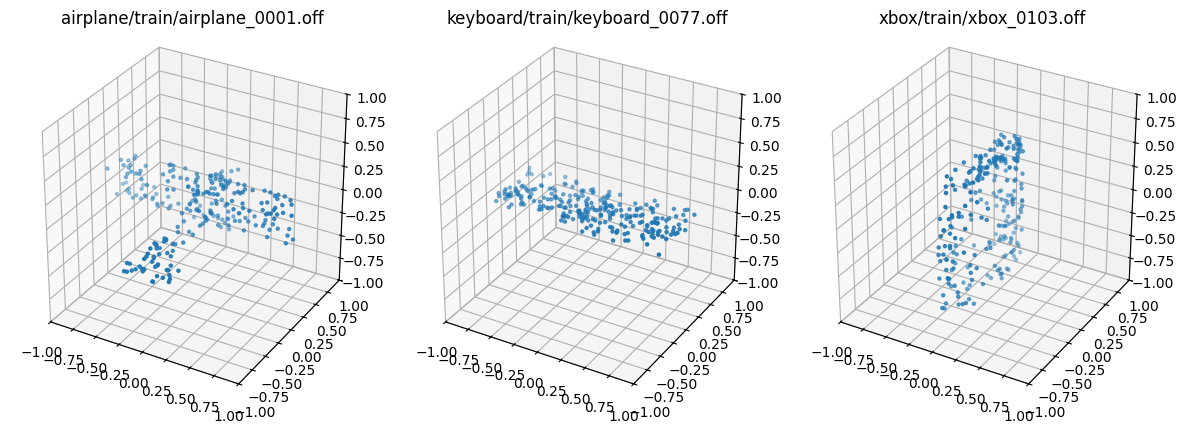

Q3.1 actual iteration-5 row-0 sum: 0.003906250931322575
Marginal target (comparison only): 0.00390625
q3_1 epoch 1: batch 100/1231
q3_1 epoch 1: batch 200/1231
q3_1 epoch 1: batch 300/1231
q3_1 epoch 1: batch 400/1231
q3_1 epoch 1: batch 500/1231
q3_1 epoch 1: batch 600/1231
q3_1 epoch 1: batch 700/1231
q3_1 epoch 1: batch 800/1231
q3_1 epoch 1: batch 900/1231
q3_1 epoch 1: batch 1000/1231
q3_1 epoch 1: batch 1100/1231
q3_1 epoch 1: batch 1200/1231
q3_1 epoch 1/20: reconstruction=0.118091, raw SWD=0.000000, total=0.118091
q3_1 epoch 2: batch 100/1231
q3_1 epoch 2: batch 200/1231
q3_1 epoch 2: batch 300/1231
q3_1 epoch 2: batch 400/1231
q3_1 epoch 2: batch 500/1231
q3_1 epoch 2: batch 600/1231
q3_1 epoch 2: batch 700/1231
q3_1 epoch 2: batch 800/1231
q3_1 epoch 2: batch 900/1231
q3_1 epoch 2: batch 1000/1231
q3_1 epoch 2: batch 1100/1231
q3_1 epoch 2: batch 1200/1231
q3_1 epoch 2/20: reconstruction=0.102629, raw SWD=0.000000, total=0.102629
q3_1 epoch 3: batch 100/1231
q3_1 epoch 3: bat

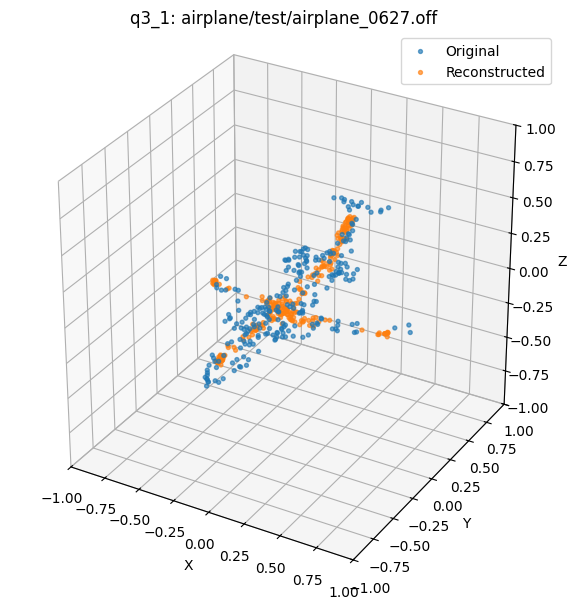

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import json
import math
import random
import hashlib
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 2026
DATA_ROOT =  Path('/kaggle/input/datasets/balraj98/modelnet40-princeton-3d-object-dataset/ModelNet40') 
OUTPUT_DIR = (Path('/kaggle/working') if Path('/kaggle/input').exists()
              else Path.cwd()) / 'ADRL_q3_outputs'
N_POINTS = 256
LATENT_DIM = 64
BATCH_SIZE = 8  # Conservative memory use for differentiating through 30 OT iterations.
EPOCHS_Q31 = 20  # Epoch count and batch size are implementation choices.
EPOCHS_Q32 = 20
EPSILON = 0.1
SINKHORN_STEPS = 30
N_DIRECTIONS = 50
LAMBDA_SWD = 1.0


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


set_seed()
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def read_off(path):
    # Handle both 'OFF\n8 6 0' and 'OFF8 6 0', plus blank/comment lines.
    with path.open() as stream:
        lines = (line.split('#', 1)[0].strip() for line in stream)
        lines = (line for line in lines if line)
        header = next(lines)
        if not header.startswith('OFF'):
            raise ValueError(f'{path}: expected an OFF mesh.')
        counts = (header[3:].strip() or next(lines)).split()
        n_vertices, n_faces = int(counts[0]), int(counts[1])
        vertices = np.array([list(map(float, next(lines).split()[:3]))
                             for _ in range(n_vertices)], dtype=np.float64)
        triangles = []
        for _ in range(n_faces):
            face = list(map(int, next(lines).split()))
            size, indices = face[0], face[1:1 + face[0]]
            if size < 3 or len(indices) != size:
                raise ValueError(f'{path}: invalid polygon.')
            if min(indices) < 0 or max(indices) >= n_vertices:
                raise ValueError(f'{path}: face index outside vertex array.')
            for j in range(1, size - 1):
                triangles.append([indices[0], indices[j], indices[j + 1]])
    if not triangles or not np.isfinite(vertices).all():
        raise ValueError(f'{path}: empty or nonfinite mesh.')
    return vertices, np.asarray(triangles, dtype=np.int64)


def surface_cloud(path, relative_name):
    vertices, faces = read_off(path)
    triangles = vertices[faces]
    area = 0.5 * np.linalg.norm(np.cross(triangles[:, 1] - triangles[:, 0],
                                       triangles[:, 2] - triangles[:, 0]), axis=1)
    good = np.isfinite(area) & (area > 0)
    triangles, area = triangles[good], area[good]
    if len(area) == 0 or not np.isfinite(area.sum()):
        raise ValueError(f'{path}: no usable surface area.')
    # Stable per-mesh RNG; sampling stays fixed across models and epochs.
    mesh_seed = int.from_bytes(hashlib.sha256(relative_name.encode()).digest()[:8], 'little')
    rng = np.random.default_rng([SEED, mesh_seed])
    selected = rng.choice(len(area), size=N_POINTS, p=area / area.sum())
    a, b, c = triangles[selected].transpose(1, 0, 2)
    r = np.sqrt(rng.random((N_POINTS, 1)))
    v = rng.random((N_POINTS, 1))
    cloud = (1 - r) * a + r * (1 - v) * b + r * v * c
    cloud -= cloud.mean(axis=0, keepdims=True)
    radius = np.linalg.norm(cloud, axis=1).max()
    if radius <= 0:
        raise ValueError(f'{path}: zero-radius cloud.')
    cloud = (cloud / radius).astype(np.float32)
    assert cloud.shape == (N_POINTS, 3) and np.isfinite(cloud).all()
    assert np.allclose(cloud.mean(0), 0, atol=1e-6)
    assert np.isclose(np.linalg.norm(cloud, axis=1).max(), 1, atol=1e-6)
    return cloud


def find_root():
    if DATA_ROOT is not None:
        root = Path(DATA_ROOT)
    else:
        base = Path('/kaggle/input') if Path('/kaggle/input').is_dir() else Path.cwd() / 'data'
        candidates = sorted({p.parent.parent.parent for p in base.rglob('*.off')
                             if p.parent.name == 'train'
                             and (p.parent.parent / 'test').is_dir()})
        if len(candidates) != 1:
            raise ValueError('Attach the extracted ModelNet40 OFF dataset and set DATA_ROOT. '
                             f'Found roots: {candidates}. HDF5 point clouds are not this guide\'s input.')
        root = candidates[0]
    if not list(root.glob('*/train/*.off')) or not list(root.glob('*/test/*.off')):
        raise ValueError(f'{root}: expected class/train/*.off and class/test/*.off.')
    return root


class ModelNetDataset(Dataset):
    def __init__(self, root, split):
        self.names = [p.relative_to(root).as_posix()
                      for p in sorted(root.glob(f'*/{split}/*.off'))]
        clouds = []
        for i, name in enumerate(self.names):
            clouds.append(surface_cloud(root / name, name))
            if (i + 1) % 500 == 0:
                print(f'{split}: sampled {i + 1}/{len(self.names)} meshes', flush=True)
        self.clouds = torch.from_numpy(np.stack(clouds))

    def __len__(self):
        return len(self.names)

    def __getitem__(self, index):
        return self.clouds[index], index


class SetAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.point_mlp = nn.Sequential(nn.Linear(3, 64), nn.ReLU(),
                                       nn.Linear(64, 128), nn.ReLU(),
                                       nn.Linear(128, 256), nn.ReLU())
        self.latent = nn.Linear(256, LATENT_DIM)
        self.decoder = nn.Sequential(nn.Linear(LATENT_DIM, 256), nn.ReLU(),
                                     nn.Linear(256, 512), nn.ReLU(),
                                     nn.Linear(512, N_POINTS * 3))

    def encode(self, x):
        # Shared MLP commutes with row permutation; max over rows is symmetric.
        # Therefore E(Pi X) = E(X). Never flatten points before pooling.
        features = self.point_mlp(x)
        return self.latent(features.max(dim=1).values)

    def decode(self, z):
        return self.decoder(z).reshape(-1, N_POINTS, 3)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z


def sinkhorn(x, y, steps=SINKHORN_STEPS, epsilon=EPSILON, capture_fifth=False):
    # C_ij = ||x_i-y_j||^2. All objects and point pairs are computed together.
    # P* minimizes <P,C> + epsilon sum(P log P), with uniform row/column masses.
    # Its positive-interior Hessian is epsilon*diag(1/P_ij), strictly positive.
    # This gives a unique positive plan for positive masses and finite costs.
    # Stationarity yields P_ij = u_i exp(-C_ij/epsilon) v_j (absorb constants).
    # With one redundant marginal constraint removed, the constrained Hessian
    # is invertible; the implicit-function theorem gives smooth dependence on C.
    # Finite unrolling is also differentiable: logsumexp, exp and sums are smooth.
    # Only a saved COPY is detached; training gradients pass through every update.
    cost = (x[:, :, None, :] - y[:, None, :, :]).square().sum(-1)
    log_kernel = -cost / epsilon
    log_a, log_b = -math.log(x.shape[1]), -math.log(y.shape[1])
    log_u = torch.zeros_like(x[:, :, 0])
    log_v = torch.zeros_like(y[:, :, 0])
    fifth = None
    # Log-domain scaling is algebraically u=a/(Kv), v=b/(K^T u),
    # but avoids kernel underflow. One iteration = one complete u THEN v update.
    for iteration in range(1, steps + 1):
        log_u = log_a - torch.logsumexp(log_kernel + log_v[:, None, :], dim=2)
        log_v = log_b - torch.logsumexp(log_kernel + log_u[:, :, None], dim=1)
        if capture_fifth and iteration == 5:
            fifth = (log_u[:, :, None] + log_kernel + log_v[:, None, :]).exp().detach().cpu()
    plan = (log_u[:, :, None] + log_kernel + log_v[:, None, :]).exp()
    # GUIDE's transport cost evaluated using the entropy-regularized plan.
    # No pointwise MSE, Chamfer, KL latent loss or debiased Sinkhorn divergence.
    loss = (plan * cost).sum(dim=(1, 2)).mean()
    return loss, plan, fifth


def make_loader(dataset):
    # Fresh generator for each model; inspection never consumes this loader.
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                      pin_memory=device.type == 'cuda',
                      generator=torch.Generator().manual_seed(SEED))


def save_results(results):
    (OUTPUT_DIR / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False))


def train_model(dataset, results, use_swd=False):
    set_seed()
    model = SetAutoencoder().to(device)
    with torch.no_grad():
        example = dataset.clouds[:2].to(device)
        permutation = torch.randperm(N_POINTS, generator=torch.Generator().manual_seed(17)).to(device)
        assert torch.allclose(model.encode(example), model.encode(example[:, permutation]), atol=1e-6)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = make_loader(dataset)
    tag = 'q3_2' if use_swd else 'q3_1'
    epochs = EPOCHS_Q32 if use_swd else EPOCHS_Q31
    direction_rng = torch.Generator(device='cpu').manual_seed(SEED)
    prior_rng = torch.Generator(device='cpu').manual_seed(SEED + 1)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        totals = np.zeros(3, dtype=np.float64)
        for batch_number, (x, indices) in enumerate(loader, start=1):
            x = x.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            reconstructed, z = model(x)
            capture = not use_swd and epoch == 1 and batch_number == 1
            reconstruction, plan, fifth = sinkhorn(x, reconstructed, capture_fifth=capture)
            if capture:
                assert fifth.shape == (len(x), N_POINTS, N_POINTS)
                assert torch.isfinite(fifth).all()
                # Actual float32 tensor reduction, saved at the requested moment.
                value = fifth[0, 0].sum().item()
                results['q3_1_transport_P_row0_sum_e1_b1_iter5'] = value
                torch.save(dict(P=fifth, row0_sum=value, epoch=1, batch=1, iterations=5,
                                files=[dataset.names[i] for i in indices.tolist()],
                                original=x.detach().cpu(), reconstructed=reconstructed.detach().cpu()),
                           OUTPUT_DIR / 'q3_1_transport_iter5.pt')
                save_results(results)
                print('Q3.1 actual iteration-5 row-0 sum:', repr(value), flush=True)
                print('Marginal target (comparison only):', 1 / N_POINTS)
            swd = z.new_zeros(())
            if use_swd:
                prior = torch.randn(z.shape, generator=prior_rng).to(device)
                directions_cpu = sample_directions(direction_rng)
                directions = directions_cpu.to(device)
                if epoch == 1 and batch_number == 1:
                    value = directions_cpu[0, 0].item()
                    results['q3_2_first_unit_direction_dim0'] = value
                    torch.save(dict(directions=directions_cpu, first_component=value,
                                    direction_seed=SEED, rng_device='cpu',
                                    prior=prior.detach().cpu(), latent=z.detach().cpu()),
                               OUTPUT_DIR / 'q3_2_first_directions.pt')
                    save_results(results)
                    print('Q3.2 first unit direction, first component:', repr(value), flush=True)
                swd = sliced_wasserstein(z, prior, directions)
            loss = reconstruction + LAMBDA_SWD * swd
            if not torch.isfinite(loss).item():
                raise FloatingPointError(f'{tag}: nonfinite loss.')
            loss.backward()
            grads = [p.grad for p in model.parameters()]
            if any(g is None for g in grads) or not torch.stack([torch.isfinite(g).all() for g in grads]).all().item():
                raise FloatingPointError(f'{tag}: missing or nonfinite gradient.')
            optimizer.step()
            totals += np.array([reconstruction.item(), swd.item(), loss.item()]) * len(x)
            if batch_number % 100 == 0:
                print(f'{tag} epoch {epoch}: batch {batch_number}/{len(loader)}', flush=True)
        row = dict(epoch=epoch, reconstruction=totals[0] / len(dataset),
                   raw_swd=totals[1] / len(dataset), total=totals[2] / len(dataset))
        history.append(row)
        print(f'{tag} epoch {epoch}/{epochs}: reconstruction={row["reconstruction"]:.6f}, '
              f'raw SWD={row["raw_swd"]:.6f}, total={row["total"]:.6f}', flush=True)
        torch.save(dict(model=model.state_dict(), optimizer=optimizer.state_dict(),
                        history=history, n_points=N_POINTS, latent_dim=LATENT_DIM,
                        epsilon=EPSILON, sinkhorn_steps=SINKHORN_STEPS), OUTPUT_DIR / f'{tag}_model.pt')
        (OUTPUT_DIR / f'{tag}_history.json').write_text(json.dumps(history, indent=2))
    return model, history


def plot_overlay(model, dataset, tag):
    model.eval()
    original = dataset.clouds[:1].to(device)
    with torch.no_grad():
        reconstructed, _ = model(original)
        # Dedicated RNG: this check cannot change the required training order.
        permutation = torch.randperm(N_POINTS, generator=torch.Generator().manual_seed(17))
        error = (model.encode(original) - model.encode(original[:, permutation.to(device)])).abs().max().item()
    if error > 1e-6:
        raise AssertionError(f'Encoder is not permutation invariant: {error}')
    print('Encoder permutation maximum error:', error)
    x, y = original[0].cpu().numpy(), reconstructed[0].cpu().numpy()
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(*x.T, s=8, alpha=0.65, label='Original')
    ax.scatter(*y.T, s=8, alpha=0.65, label='Reconstructed')
    limit = float(max(np.abs(x).max(), np.abs(y).max(), 1))
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), zlim=(-limit, limit),
           xlabel='X', ylabel='Y', zlabel='Z', title=f'{tag}: {dataset.names[0]}')
    ax.set_box_aspect((1, 1, 1))
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{tag}_overlay.png', dpi=130)
    plt.show()
    plt.close(fig)
    torch.save(dict(original=original.cpu(), reconstructed=reconstructed.cpu(),
                    file=dataset.names[0], permutation_error=error), OUTPUT_DIR / f'{tag}_overlay.pt')


def run_q31():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    root = find_root()
    print('Device:', device, '| Dataset:', root, flush=True)
    if device.type == 'cpu':
        print('For faster training, select a Kaggle GPU accelerator.', flush=True)
    train_data, test_data = ModelNetDataset(root, 'train'), ModelNetDataset(root, 'test')
    fig = plt.figure(figsize=(12, 4))
    for panel, index in enumerate(np.linspace(0, len(train_data) - 1, min(3, len(train_data)), dtype=int), 1):
        ax = fig.add_subplot(1, 3, panel, projection='3d')
        ax.scatter(*train_data.clouds[index].numpy().T, s=5)
        ax.set(title=train_data.names[index], xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1))
        ax.set_box_aspect((1, 1, 1))
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'sampled_clouds_preview.png', dpi=130)
    plt.show()
    plt.close(fig)
    # Store the exact sampled sets and file order once for audit/reuse.
    torch.save(dict(train=train_data.clouds, test=test_data.clouds,
                    train_files=train_data.names, test_files=test_data.names), OUTPUT_DIR / 'sampled_clouds.pt')
    audit = dict(seed=SEED, dataset='ModelNet40 OFF meshes (GUIDE substitution)',
                 root=str(root), train_count=len(train_data), test_count=len(test_data),
                 n_points=N_POINTS, latent_dim=LATENT_DIM, batch_size=BATCH_SIZE,
                 epochs_q31=EPOCHS_Q31, epochs_q32=EPOCHS_Q32, epsilon=EPSILON,
                 sinkhorn_steps=SINKHORN_STEPS, lambda_swd=LAMBDA_SWD,
                 torch_version=torch.__version__, numpy_version=np.__version__,
                 device=str(device), direction_rng='CPU torch.Generator, seed 2026',
                 prior_rng='separate CPU torch.Generator, seed 2027',
                 gpu=torch.cuda.get_device_name(0) if device.type == 'cuda' else None)
    (OUTPUT_DIR / 'data_audit.json').write_text(json.dumps(audit, indent=2))
    results = {}
    model, history = train_model(train_data, results)
    plot_overlay(model, test_data, 'q3_1')
    return train_data, test_data, results


if __name__ == '__main__':
    train_data, test_data, results = run_q31()



## Q3.2 — Sliced Wasserstein autoencoder

Draw $g\sim\mathcal N(0,I_D)$ and set $\theta=g/\|g\|_2$. The event $g=0$ has probability zero. For any orthogonal matrix $R$, $Rg$ has the same distribution as $g$ and $\|Rg\|=\|g\|$. Therefore $R\theta$ has the same distribution as $\theta$: it is rotation-invariant and supported on the unit sphere. The unique normalized rotation-invariant measure there is the uniform surface measure. Thus normalized independent Gaussian vectors give uniform random directions, unlike normalizing a vector drawn uniformly from a cube.

For 50 such directions, project encoded and Gaussian-prior batches, sort along the sample axis, and calculate

$$
\mathrm{SWD}=\frac1{50B}\sum_{\ell=1}^{50}\sum_{i=1}^B
\left[\operatorname{sort}(Z\theta_\ell)_i-\operatorname{sort}(Z_{\rm prior}\theta_\ell)_i\right]^2.
$$

For equally weighted empirical distributions, sorted samples are their empirical quantiles, so this computes the one-dimensional squared Wasserstein distance for each projection. Sorting approximates the quantile comparison, not a pointwise comparison of unsorted samples or CDF heights.

Train a separate ModelNet40 set autoencoder with the transport-cost reconstruction described in Q3.1 plus this SWD penalty (weight 1). Directions are sampled using a dedicated CPU generator seeded with 2026; the prior uses a separate generator seeded with 2027. Print the first coordinate of the first direction actually used in training, and plot the **unscaled** SWD penalty against epoch.

Q3.2 first unit direction, first component: -0.02479434385895729
q3_2 epoch 1: batch 100/1231
q3_2 epoch 1: batch 200/1231
q3_2 epoch 1: batch 300/1231
q3_2 epoch 1: batch 400/1231
q3_2 epoch 1: batch 500/1231
q3_2 epoch 1: batch 600/1231
q3_2 epoch 1: batch 700/1231
q3_2 epoch 1: batch 800/1231
q3_2 epoch 1: batch 900/1231
q3_2 epoch 1: batch 1000/1231
q3_2 epoch 1: batch 1100/1231
q3_2 epoch 1: batch 1200/1231
q3_2 epoch 1/20: reconstruction=0.124311, raw SWD=0.591303, total=0.715614
q3_2 epoch 2: batch 100/1231
q3_2 epoch 2: batch 200/1231
q3_2 epoch 2: batch 300/1231
q3_2 epoch 2: batch 400/1231
q3_2 epoch 2: batch 500/1231
q3_2 epoch 2: batch 600/1231
q3_2 epoch 2: batch 700/1231
q3_2 epoch 2: batch 800/1231
q3_2 epoch 2: batch 900/1231
q3_2 epoch 2: batch 1000/1231
q3_2 epoch 2: batch 1100/1231
q3_2 epoch 2: batch 1200/1231
q3_2 epoch 2/20: reconstruction=0.110351, raw SWD=0.541271, total=0.651622
q3_2 epoch 3: batch 100/1231
q3_2 epoch 3: batch 200/1231
q3_2 epoch 3: batch 300/1

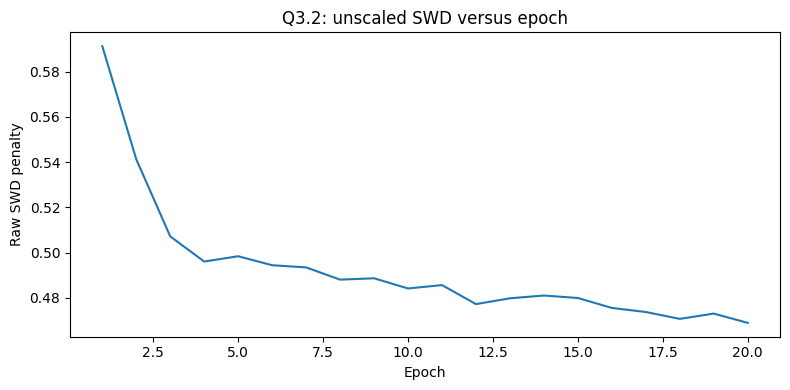

Encoder permutation maximum error: 0.0


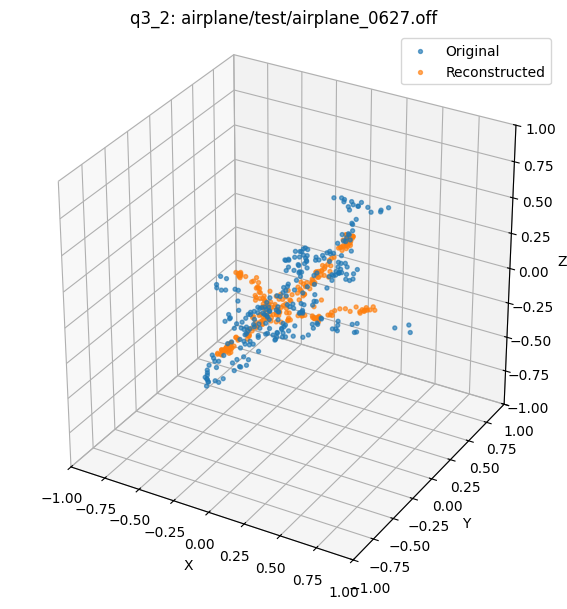

{
  "q3_1_transport_P_row0_sum_e1_b1_iter5": 0.003906250931322575,
  "q3_2_first_unit_direction_dim0": -0.02479434385895729
}
Saved outputs: /kaggle/working/ADRL_q3_outputs


In [2]:
def sample_directions(generator):
    gaussian = torch.randn(N_DIRECTIONS, LATENT_DIM, generator=generator)
    norms = torch.linalg.vector_norm(gaussian, dim=1, keepdim=True)
    if (norms == 0).any():
        raise FloatingPointError('Unexpected zero Gaussian direction.')
    directions = gaussian / norms
    assert directions.shape == (50, LATENT_DIM)
    assert torch.allclose(directions.norm(dim=1), torch.ones(50), atol=1e-6)
    return directions


def sliced_wasserstein(z, prior, directions):
    encoded_projection = z @ directions.T  # [B,50]
    prior_projection = prior @ directions.T
    encoded_sorted = encoded_projection.sort(dim=0).values  # Sort over samples.
    prior_sorted = prior_projection.sort(dim=0).values
    return (encoded_sorted - prior_sorted).square().mean()


def run_q32(train_data, test_data, results):
    model, history = train_model(train_data, results, use_swd=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot([row['epoch'] for row in history], [row['raw_swd'] for row in history])
    ax.set(xlabel='Epoch', ylabel='Raw SWD penalty', title='Q3.2: unscaled SWD versus epoch')
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / 'q3_2_raw_swd.png', dpi=130)
    plt.show()
    plt.close(fig)
    plot_overlay(model, test_data, 'q3_2')
    save_results(results)
    print(json.dumps(results, indent=2))
    print('Saved outputs:', OUTPUT_DIR)


if __name__ == '__main__':
    assert 'train_data' in globals(), 'Run the Q3.1 cell first.'
    run_q32(train_data, test_data, results)


## Recorded numerical checks

These values are copied from the saved outputs of the original notebooks, not newly computed results.

| Question | Check | Recorded value |
|---|---|---:|
| Q1.1 | First-convolution gradient L2 norm, epoch 1 batch 1 | 0.6918411048350842 |
| Q1.2 | Latent Euclidean distance after 50 steps | 0.4715159265971222 |
| Q1.3 | Unscaled gradient penalty at epsilon = 0.5 | 0.9948620796203613 |
| Q1.4 | Real-feature covariance trace | 464.38800910188684 |
| Q1.4 | WGAN-GP FFD | 285.21221834766965 |
| Q2.1 | Epoch-10/11 latent cosine similarity | 0.8071993089835765 |
| Q2.2 | Highest-variance coordinate index | 0 |
| Q2.2 | Highest coordinate variance | 0.9790308768067651 |
| Q2.3 | Epoch-1 maximum off-diagonal codebook cosine similarity | 0.9968832157217792 |
| Q2.4 | Generated V maximum amplitude, normalized units | 4.110568523406982 |
| Q3.1 | Iteration-5 transport first-row sum | 0.003906250931322575 |
| Q3.2 | First coordinate of the first random unit direction | -0.02479434385895729 |